# Neuro-Symbolic Intrusion Detection for Resource-Constrained IIoT/ICS/SCADA Environments

**A hybrid neural-symbolic framework designed for real-world edge deployment in Industrial Internet of Things (IIoT), Industrial Control Systems (ICS), and SCADA networks.**

### Why Neuro-Symbolic?
Modern IIoT/ICS environments face severe constraints:
- Extremely limited compute and memory on PLCs, RTUs, and edge gateways
- Strict real-time requirements (sub-millisecond decisions)
- High class imbalance and evolving attack patterns
- Need for interpretability and trust in safety-critical systems

Pure deep learning models often achieve high accuracy but lack explainability and are too heavy for edge devices. Pure symbolic/rule-based systems are lightweight and interpretable but struggle with complex temporal patterns.

This project introduces a neuro-symbolic fusion architecture that combines the temporal modelling power of a GRU neural network with a lightweight, rule-calibrated symbolic component, delivering both high detection performance and edge-friendly characteristics.

### Architecture Overview
- **Neural Component**: GRU-based temporal model (sequence-aware)  
- **Symbolic Component**: Shallow, interpretable decision tree / ontology learned from training data  
- **Fusion**: Learned weighted combination of neural and symbolic scores  
- **Target Deployment**: Resource-constrained edge devices (sub-millisecond latency, low memory footprint)

### Datasets Used
- **CIC-DDoS2019** - Volumetric DDoS attacks (SYN, UDP, NTP, TFTP floods)
- **Edge-IIoTset** - Realistic IoT/IIoT attack scenarios
- **CICIoT2023** - Large-scale modern IoT traffic with diverse attacks

### Project Goals
- Achieve **≥ 98% F1-score** across all datasets with the hybrid model
- Maintain **sub-millisecond single-packet inference latency**
- Keep memory footprint low enough for real edge gateway deployment
- Provide **interpretable symbolic rules** alongside high neural performance


**Notebook Structure**
1. Data Loading (CIC-DDoS2019, Edge-IIoTset, CICIoT2023)
2. Feature Engineering & Scaling
3. GRU Training (temporal neural model)
4. Symbolic Ontology Construction
5. Neuro-Symbolic Fusion & Evaluation
6. Publication Figures (bar charts, confusion matrices, ROC/PR curves)
7. Inference Benchmark (latency & throughput)
8. LaTeX-ready tables

*Last updated: May 2026*

In [109]:
# CELL 1: Environment Setup & Global Configuration
import os
import platform
import random
import warnings
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.cluster import MiniBatchKMeans

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
from tqdm import tqdm

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("CELL 1: Environment Setup & Global Configuration\n")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device & Hardware Settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_CORES = os.cpu_count() or 4

torch.set_num_threads(N_CORES)

# Safe interop threads setting (prevents RuntimeError)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass   # already set by background processes

print(f"Device          : {device}")
print(f"CPU Threads     : {torch.get_num_threads()} (compute) | {torch.get_num_interop_threads()} (interop)")

# Global Hyperparameters
SEQ_LEN        = 16   # Sliding window length
BATCH_TRAIN    = 256
BATCH_INFER    = 512
EPOCHS         = 20
LR             = 3e-3
HIDDEN_SIZE    = 64
GRU_LAYERS     = 2
DROPOUT        = 0.25
N_WORKERS      = min(4, N_CORES)

# Output Directory
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

print(f"Output directory: {OUT.resolve()}")
print(f"SEQ_LEN={SEQ_LEN} | BATCH={BATCH_TRAIN} | EPOCHS={EPOCHS} | HIDDEN={HIDDEN_SIZE}")
print("Setup completed successfully.\n")

CELL 1: Environment Setup & Global Configuration

Device          : cpu
CPU Threads     : 16 (compute) | 1 (interop)
Output directory: F:\jupyter\outputs
SEQ_LEN=16 | BATCH=256 | EPOCHS=20 | HIDDEN=64
Setup completed successfully.



In [110]:
# CELL 2: Dataset Paths
# stratified subsampling is used only when memory would be exceeded.

BASE_PATH = Path(r'F:\jupyter\kagglehub')

DATASET_PATHS = {
    'cic_ddos19': {
        'root': BASE_PATH / r'datasets\dhoogla\cicddos2019\versions\3',
        'split': False
    },
    'edge_iiotset': {
        'root': BASE_PATH / r'edgeiiotset-cyber-security-dataset-of-iot-iiot\versions\5'
                           r'\Edge-IIoTset dataset\Selected dataset for ML and DL',
        'split': False
    },
    'ciciot23': {
        'train': BASE_PATH / r'CICIOT23\train\train.csv',
        'val':   BASE_PATH / r'CICIOT23\validation\validation.csv',
        'test':  BASE_PATH / r'CICIOT23\test\test.csv',
        'split': True
    }
}

print('Dataset paths configured.')
for k, v in DATASET_PATHS.items():
    if v['split']:
        exists = all(Path(v[s]).exists() for s in ['train', 'val', 'test'])
    else:
        exists = v['root'].exists()
    status = 'FOUND' if exists else ' NOT FOUND'
    print(f'  {k}: {status}')

Dataset paths configured.
  cic_ddos19: FOUND
  edge_iiotset: FOUND
  ciciot23: FOUND


In [111]:
# CELL 3: CIC-DDoS / Edge-IIoT / CICIOT23 Loader 
print("CELL 3: Loading datasets \n")

from pathlib import Path
import pandas as pd
import numpy as np

base_path = Path(r"F:\jupyter\kagglehub")
paths = {
    "cic_ddos": base_path / r"datasets\dhoogla\cicddos2019\versions\3",
    "edge_iot": base_path / r"edgeiiotset-cyber-security-dataset-of-iot-iiot\versions\5\Edge-IIoTset dataset\Selected dataset for ML and DL",
    "ciciot23": base_path / r"CICIOT23"
}

datasets = {}

# Label conversion
def to_binary(x):
    if pd.isna(x):
        return 0
    x = str(x).lower()
    return 0 if ("normal" in x or "benign" in x or x == "0") else 1

# File reader
def read_any(f):
    try:
        if f.suffix == ".csv":
            return pd.read_csv(f, low_memory=False)
        elif f.suffix == ".parquet":
            return pd.read_parquet(f)
        else:
            return None
    except Exception as e:
        print(f" [!] Could not read {f.name}: {e}")
        return None

# Numeric column extractor (protects 'target')
def get_numeric_cols(df):
    df = df.copy()
    
    # Saving target column before dropping anything
    target_exists = "target" in df.columns
    target_col = df["target"].copy() if target_exists else None
    
    # Identifying columns to drop (object / category, except target)
    drop_dtypes = ["object", "category"]
    bad_cols = [
        c for c in df.columns
        if c != "target" and (
            df[c].dtype.name in drop_dtypes or 
            hasattr(df[c], "cat") or 
            pd.api.types.is_object_dtype(df[c])
        )
    ]
    
    df.drop(columns=bad_cols, inplace=True)
    
    # Coercing remaining columns to numeric (skipping target)
    for col in list(df.columns):
        if col == "target":
            continue
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Droping columns that became all-NaN
    df.dropna(axis=1, how="all", inplace=True)
    
    # Restoring target column if it was accidentally dropped
    if target_exists and "target" not in df.columns:
        df["target"] = target_col
    
    num_cols = [c for c in df.columns if c != "target"]
    return df, num_cols

# Dataset loader
def load_dataset(root):
    files = list(root.rglob("*.csv")) + list(root.rglob("*.parquet"))
    if not files:
        print(f" No files found in {root}")
        return None
    
    dfs = []
    for f in files:
        df = read_any(f)
        if df is None:
            continue
            
        # Detect label column
        label_col = None
        for c in ["Label", "label", "Attack_type", "attack_type", "class"]:
            if c in df.columns:
                label_col = c
                break
                
        if label_col is None:
            print(f" [!] No label column found in {f.name} - skipping")
            continue
        
        # Creating target brfore cleaning
        df["target"] = df[label_col].apply(to_binary)
        df["target"] = pd.to_numeric(df["target"], errors="coerce").fillna(0).astype("int8")
        
        # Extracting numeric features
        df, num_cols = get_numeric_cols(df)
        
        if not num_cols:
            print(f" [!] No numeric columns in {f.name} - skipping")
            continue
            
        # Safe column selection
        cols_to_keep = num_cols + ["target"]
        df = df[cols_to_keep]
        
        dfs.append(df)
        
        n_att = df["target"].sum()
        print(f" {f.name}: {len(df):>10,} rows "
              f"(attack={n_att:,} / benign={len(df)-n_att:,})")
    
    if not dfs:
        return None
    
    df_all = pd.concat(dfs, ignore_index=True)
    df_all.fillna(0, inplace=True)
    return df_all

# CICIOT23 split loader
def load_split(p):
    df = read_any(Path(p))
    if df is None:
        raise IOError(f"Cannot read {p}")
    
    label_col = None
    for c in ["Label", "label", "Attack_type", "attack_type", "class"]:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"No label column in {p}")
    
    df["target"] = df[label_col].apply(to_binary)
    df["target"] = pd.to_numeric(df["target"], errors="coerce").fillna(0).astype("int8")
    
    df, num_cols = get_numeric_cols(df)
    cols_to_keep = num_cols + ["target"]
    df = df[cols_to_keep]
    df.fillna(0, inplace=True)
    return df

# Load CIC-DDoS
print("Loading CIC-DDoS...")
cic = load_dataset(paths["cic_ddos"])
datasets["cic_ddos"] = {
    "df": cic,
    "features": [c for c in cic.columns if c != "target"]
}
print(f"CIC-DDoS total: {len(cic):,} rows | features: {len(datasets['cic_ddos']['features'])}\n")

# Load Edge-IIoTset
print("Loading Edge-IIoTset...")
edge = load_dataset(paths["edge_iot"])
datasets["edge_iot"] = {
    "df": edge,
    "features": [c for c in edge.columns if c != "target"]
}
print(f"Edge-IIoTset total: {len(edge):,} rows | features: {len(datasets['edge_iot']['features'])}\n")

# Load CICIOT23

print("Loading CICIOT23...")
train = load_split(paths["ciciot23"] / "train/train.csv")
val = load_split(paths["ciciot23"] / "validation/validation.csv")
test = load_split(paths["ciciot23"] / "test/test.csv")

datasets["ciciot23"] = {
    "train": train,
    "val": val,
    "test": test,
    "features": [c for c in train.columns if c != "target"]
}
print(f"CICIOT23 train={len(train):,} val={len(val):,} test={len(test):,}")
print(f" features: {len(datasets['ciciot23']['features'])}")

print("\nCELL 3 COMPLETE")

CELL 3: Loading datasets 

Loading CIC-DDoS...
 DNS-testing.parquet:      6,703 rows (attack=3,669 / benign=3,034)
 LDAP-testing.parquet:      2,831 rows (attack=1,440 / benign=1,391)
 LDAP-training.parquet:      6,715 rows (attack=2,130 / benign=4,585)
 MSSQL-testing.parquet:      8,083 rows (attack=6,212 / benign=1,871)
 MSSQL-training.parquet:     10,974 rows (attack=8,400 / benign=2,574)
 NetBIOS-testing.parquet:      2,225 rows (attack=598 / benign=1,627)
 NetBIOS-training.parquet:      1,631 rows (attack=398 / benign=1,233)
 NTP-testing.parquet:    134,674 rows (attack=121,368 / benign=13,306)
 Portmap-training.parquet:      5,105 rows (attack=685 / benign=4,420)
 SNMP-testing.parquet:      4,018 rows (attack=2,717 / benign=1,301)
 Syn-testing.parquet:        907 rows (attack=533 / benign=374)
 Syn-training.parquet:     70,336 rows (attack=43,302 / benign=27,034)
 TFTP-testing.parquet:    121,833 rows (attack=98,917 / benign=22,916)
 UDP-testing.parquet:     12,462 rows (attack=1

In [112]:
# CELL 4: Feature Engineering & Scaling
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

print("CELL 4: Feature Engineering & Scaling\n")

# Constants
SEED = 42
# Helper functions
def remove_low_variance(df, feats, threshold=1e-6):
    var = df[feats].var()
    keep = var[var > threshold].index.tolist()
    dropped = len(feats) - len(keep)
    if dropped:
        print(f'   Dropped {dropped} near-zero-variance features')
    return keep

def remove_high_correlation(df, feats, threshold=0.98):
    # Using sample for speed on large/wide datasets
    sample_size = min(50_000, len(df))
    sample = df[feats].sample(sample_size, random_state=SEED)
    corr = sample.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [c for c in upper.columns if (upper[c] > threshold).any()]
    keep = [c for c in feats if c not in drop]
    if drop:
        print(f'   Dropped {len(drop)} high-correlation features (>{threshold})')
    return keep

# Main processing
scalers = {}
feat_cols = {}

for name, data in datasets.items():
    print(f'[{name.upper()}]')
    
    feats = data.get('features', [])
    
    # CIC-DDoS & Edge-IIoT (flat data)
    if name in ['cic_ddos', 'edge_iot']:
        df = data['df']
        
        X = np.nan_to_num(df[feats].values, nan=0.0, posinf=0.0, neginf=0.0)
        y = df['target'].values.astype(np.int64)
        
        # Train / Val / Test split (70% / 12.5% / 17.5%)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=SEED)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=SEED)
        
        tr_df = pd.DataFrame(X_tr, columns=feats)
        
        # Feature selection on training data only
        kept = remove_low_variance(tr_df, feats)
        kept = remove_high_correlation(tr_df[kept], kept)
        
        feat_cols[name] = kept
        col_idx = [feats.index(c) for c in kept]
        
        scaler = RobustScaler()
        scaler.fit(X_tr[:, col_idx])
        
        datasets[name]['X_train'] = scaler.transform(X_tr[:, col_idx]).astype(np.float32)
        datasets[name]['X_val']   = scaler.transform(X_val[:, col_idx]).astype(np.float32)
        datasets[name]['X_test']  = scaler.transform(X_te[:, col_idx]).astype(np.float32)
        
        datasets[name]['y_train'] = y_tr
        datasets[name]['y_val']   = y_val
        datasets[name]['y_test']  = y_te
        
    # CICIOT23 (loadedalready pre-split)
    else:  # ciciot23
        tr_df = data['train']
        val_df = data['val']
        te_df = data['test']
        
        X_tr = np.nan_to_num(tr_df[feats].values, nan=0.0, posinf=0.0, neginf=0.0)
        X_val = np.nan_to_num(val_df[feats].values, nan=0.0, posinf=0.0, neginf=0.0)
        X_te = np.nan_to_num(te_df[feats].values, nan=0.0, posinf=0.0, neginf=0.0)
        
        tr_pd = pd.DataFrame(X_tr, columns=feats)
        
        kept = remove_low_variance(tr_pd, feats)
        kept = remove_high_correlation(tr_pd[kept], kept)
        
        feat_cols[name] = kept
        col_idx = [feats.index(c) for c in kept]
        
        scaler = RobustScaler()
        scaler.fit(X_tr[:, col_idx])
        
        datasets[name]['X_train'] = scaler.transform(X_tr[:, col_idx]).astype(np.float32)
        datasets[name]['X_val']   = scaler.transform(X_val[:, col_idx]).astype(np.float32)
        datasets[name]['X_test']  = scaler.transform(X_te[:, col_idx]).astype(np.float32)
        
        datasets[name]['y_train'] = tr_df['target'].values.astype(np.int64)
        datasets[name]['y_val']   = val_df['target'].values.astype(np.int64)
        datasets[name]['y_test']  = te_df['target'].values.astype(np.int64)
    
    # Store scaler and print summary
    scalers[name] = scaler
    n_kept = len(feat_cols[name])
    tr_pos = datasets[name]['y_train'].sum()
    tr_tot = len(datasets[name]['y_train'])
    
    print(f'   Features kept : {n_kept}')
    print(f'   Train         : {tr_tot:,} (attack rate {tr_pos/tr_tot*100:.1f}%)')
    print(f'   Val           : {len(datasets[name]["y_val"]):,}')
    print(f'   Test          : {len(datasets[name]["y_test"]):,}\n')

print('Cell 4 complete.')

CELL 4: Feature Engineering & Scaling

[CIC_DDOS]
   Dropped 12 near-zero-variance features
   Dropped 15 high-correlation features (>0.98)
   Features kept : 50
   Train         : 301,959 (attack rate 77.3%)
   Val           : 43,137
   Test          : 86,275

[EDGE_IOT]
   Dropped 4 near-zero-variance features
   Dropped 6 high-correlation features (>0.98)
   Features kept : 33
   Train         : 1,663,900 (attack rate 31.0%)
   Val           : 237,700
   Test          : 475,401

[CICIOT23]
   Dropped 4 near-zero-variance features
   Dropped 6 high-correlation features (>0.98)
   Features kept : 36
   Train         : 5,491,971 (attack rate 97.6%)
   Val           : 1,176,851
   Test          : 1,176,851

Cell 4 complete.


In [113]:
# CELL 5: Improved GRU Training
print('CELL 5: Stronger GRU Training \n')

# Runtime flags
IS_WINDOWS = platform.system() == 'Windows'
NUM_WORKERS = 0 if IS_WINDOWS else min(4, os.cpu_count() or 4)
USE_COMPILE = hasattr(torch, 'compile')

# Stronger hyperparameters
SEQ_LEN = 16
HIDDEN_SIZE = 64
GRU_LAYERS = 2
DROPOUT = 0.25
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-3
PATIENCE = 5

device = torch.device('cpu')

# Model and Dataset classes
class GRUClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.norm = nn.LayerNorm(input_size)
        self.gru = nn.GRU(input_size, HIDDEN_SIZE, GRU_LAYERS,
                          batch_first=True, dropout=DROPOUT if GRU_LAYERS > 1 else 0.0)
        self.drop = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        x = self.norm(x)
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :]))

class SlidingWindowDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y = torch.from_numpy(y.astype(np.float32))
        self.seq_len = seq_len
        self.n = max(0, len(X) - seq_len + 1)
    def __len__(self): return self.n
    def __getitem__(self, i):
        return self.X[i:i+self.seq_len], self.y[i+self.seq_len-1]

# History dictionary
train_histories = {}

for ds_name, data in datasets.items():
    print(f'\n{"-"*70}\nTraining on: {ds_name.upper()}\n{"-"*70}')
    if 'X_train' not in data: continue

    X_tr = data['X_train']
    y_tr = data['y_train']
    X_val = data.get('X_val')
    y_val = data.get('y_val')

    if len(X_tr) <= SEQ_LEN: continue

    train_dataset = SlidingWindowDataset(X_tr, y_tr, SEQ_LEN)
    tr_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=False)

    val_loader = None
    if X_val is not None and len(X_val) > SEQ_LEN:
        val_dataset = SlidingWindowDataset(X_val, y_val, SEQ_LEN)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2,
                                shuffle=False, num_workers=NUM_WORKERS)

    model = GRUClassifier(input_size=X_tr.shape[1]).to(device)
    if USE_COMPILE:
        try: model = torch.compile(model, mode='reduce-overhead')
        except: pass

    n_pos = int(y_tr.sum())
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(len(y_tr)-n_pos)/(n_pos+1e-8)]))
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR,
                                              total_steps=EPOCHS*len(tr_loader))

    best_f1, best_state = 0.0, None
    history = []

    for epoch in range(1, EPOCHS+1):
        model.train()
        ep_loss = 0.0
        for xb, yb in tqdm(tr_loader, desc=f'E{epoch:02d}', leave=False):
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            ep_loss += loss.item()

        avg_loss = ep_loss / len(tr_loader)

        # Validation F1
        val_f1 = 0.0
        if val_loader:
            model.eval()
            with torch.no_grad():
                vp, vy = [], []
                for xb, yb in val_loader:
                    vp.extend(torch.sigmoid(model(xb)).squeeze(1).cpu().numpy())
                    vy.extend(yb.cpu().numpy())
                val_f1 = f1_score(vy, (np.array(vp) >= 0.5).astype(int), zero_division=0)

        history.append({'epoch': epoch, 'loss': avg_loss, 'val_f1': val_f1})

        print(f' E{epoch:02d} | loss={avg_loss:.4f} | val_F1={val_f1:.4f}')

    # Save model and history
    train_histories[ds_name] = history
    save_path = f'gru_{ds_name}.pth'
    torch.save(model.state_dict(), save_path)
    print(f'   Model + history saved - {save_path}\n')

print('\n CELL 5 COMPLETE; Training history saved')

CELL 5: Stronger GRU Training 


----------------------------------------------------------------------
Training on: CIC_DDOS
----------------------------------------------------------------------


 E01 | loss=0.1877 | val_F1=0.9402


 E02 | loss=0.0714 | val_F1=0.9584


 E03 | loss=0.0546 | val_F1=0.9636


 E04 | loss=0.0424 | val_F1=0.9708


...

 E16 | loss=0.0019 | val_F1=0.9917


 E17 | loss=0.0019 | val_F1=0.9916


 E18 | loss=0.0019 | val_F1=0.9915


 E19 | loss=0.0019 | val_F1=0.9917


 E20 | loss=0.0018 | val_F1=0.9916
   Model + history saved - gru_ciciot23.pth


 CELL 5 COMPLETE; Training history saved


In [114]:
# CELL 6: BEST PERFORMING Symbolic -shallow DT

from sklearn.tree import DecisionTreeClassifier
import numpy as np

print("CELL 7: BEST Symbolic Component -Shallow DT\n")

SEED = 42
symbolic_models = {}

for name, data in datasets.items():
    print(f'[{name.upper()}] - Training best shallow Decision Tree')
    
    kept_features = feat_cols[name]
    print(f'   Using {len(kept_features)} selected features')
    
    # Getting training data (same features as neural model)
    if name in ['cic_ddos', 'edge_iot']:
        X_tr = data['df'][kept_features].values.astype(np.float32)
        y_tr = data['df']['target'].values
    else:  # ciciot23
        X_tr = data['train'][kept_features].values.astype(np.float32)
        y_tr = data['train']['target'].values
    
    X_tr = np.nan_to_num(X_tr, nan=0.0)
    
    # Best parameters found (balanced performance across all datasets)
    if name == 'edge_iot':
        max_d = 4
        min_leaf = 80
    else:
        max_d = 5
        min_leaf = 40
    
    dt = DecisionTreeClassifier(
        max_depth=max_d,
        min_samples_leaf=min_leaf,
        min_samples_split=100,
        class_weight='balanced',
        random_state=SEED
    )
    dt.fit(X_tr, y_tr)
    
    symbolic_models[name] = dt
    
    # Diagnostics
    depth = dt.get_depth()
    leaves = dt.get_n_leaves()
    train_prob = dt.predict_proba(X_tr)[:, 1]
    print(f'   Tree depth = {depth} | leaves = {leaves}')
    print(f'   Symbolic score range: [{train_prob.min():.3f} - {train_prob.max():.3f}]\n')

print(' BEST Symbolic Decision Tree ready')

CELL 7: BEST Symbolic Component -Shallow DT

[CIC_DDOS] - Training best shallow Decision Tree
   Using 50 selected features
   Tree depth = 5 | leaves = 25
   Symbolic score range: [0.000 - 1.000]

[EDGE_IOT] - Training best shallow Decision Tree
   Using 33 selected features
   Tree depth = 2 | leaves = 4
   Symbolic score range: [0.000 - 1.000]

[CICIOT23] - Training best shallow Decision Tree
   Using 36 selected features
   Tree depth = 5 | leaves = 24
   Symbolic score range: [0.000 - 1.000]

 BEST Symbolic Decision Tree ready


In [115]:
# CELL 7: Neuro-Symbolic Probability Extraction
print("CELL 8: Extracting Neural + Symbolic Probabilities (Decision Tree symbolic)\n")

# Settings
SEQ_LEN = 8                 
BATCH_INFER = 1024
device = torch.device('cpu')

# Helper Functions
def extract_neural_probs(model, X, y, seq_len=SEQ_LEN):
    """Extract neural (GRU) probabilities using sliding window"""
    dataset = SlidingWindowDataset(X, y, seq_len)          # From CELL 5
    loader = DataLoader(
        dataset,
        batch_size=BATCH_INFER,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )
    
    probs, labels = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Neural inference", leave=False, ncols=80):
            xb = xb.to(device)
            p = torch.sigmoid(model(xb)).cpu().numpy().flatten()
            probs.extend(p)
            labels.extend(yb.numpy())
    
    return np.array(probs, dtype=np.float32), np.array(labels, dtype=np.int64)


def extract_symbolic_probs(X, name, seq_len=SEQ_LEN):
    """Extract symbolic probabilities from Decision Tree (new symbolic component)"""
    model = symbolic_models[name]
    
    # Using the last observation of each sliding window -matches neural alignment
    X_pts = X[seq_len-1:] # shape (N-seq_len+1, F)
    X_pts = np.nan_to_num(X_pts, nan=0.0).astype(np.float32)
    
    # Decision Tree probability of attack class
    return model.predict_proba(X_pts)[:, 1].astype(np.float32)


# Main Extraction 
neural_probs = {}
symbolic_probs = {}
y_splits = {}

for name, data in datasets.items():
    print(f'[{name.upper()}] - Extracting probabilities')
    
    model = trained_models[name]
    
    for split in ('train', 'val', 'test'):
        key = f'X_{split}'
        if key not in data:
            print(f'   Skipping {split} - {key} not found')
            continue
            
        X = data[f'X_{split}']
        y = data[f'y_{split}']
        
        # Neural probabilities (GRU)
        n_probs, n_labels = extract_neural_probs(model, X, y)
        
        # Symbolic probabilities (Decision Tree)
        s_probs = extract_symbolic_probs(X, name)
        
        # Aligning lengths (symbolic is offset by SEQ_LEN-1)
        min_len = min(len(n_probs), len(s_probs))
        n_probs = n_probs[:min_len]
        s_probs = s_probs[:min_len]
        n_labels = n_labels[:min_len]
        
        neural_probs.setdefault(name, {})[split] = n_probs
        symbolic_probs.setdefault(name, {})[split] = s_probs
        y_splits.setdefault(name, {})[split] = n_labels
        
        print(f'   {split:5s}: {len(n_probs):>10,} windows | '
              f'attacks = {n_labels.sum():,}')
    
    print('')

print('Neuro-Symbolic probability extraction complete.')

CELL 8: Extracting Neural + Symbolic Probabilities (Decision Tree symbolic)

[CIC_DDOS] - Extracting probabilities


   train:    301,952 windows | attacks = 233,471


   val  :     43,130 windows | attacks = 33,350


   test :     86,268 windows | attacks = 66,704

[EDGE_IOT] - Extracting probabilities


   train:  1,663,893 windows | attacks = 515,937


   val  :    237,693 windows | attacks = 73,705


   test :    475,394 windows | attacks = 147,411

[CICIOT23] - Extracting probabilities


   train:  5,491,964 windows | attacks = 5,362,426


   val  :  1,176,844 windows | attacks = 1,149,326


   test :  1,176,844 windows | attacks = 1,149,135

Neuro-Symbolic probability extraction complete.


In [116]:
# CELL 9:  Fusion Weight Optimisation (α search)
# hybrid_score = α × neural + (1-α) × symbolic

# Both α and decision threshold are jointly optimised on the validation set
# using F1 as the criterion 
# NumPy broadcasting vectorises the entire grid, no Python loops over N.

ALPHAS      = np.linspace(0.0, 1.0, 41)   # 0.025 resolution
THRESHOLDS  = np.linspace(0.05, 0.95, 37) # 0.025 resolution

alpha_opt   = {}
thresh_opt  = {}
val_f1_opt  = {}

for name in neural_probs:
    n_val = neural_probs[name]['val']
    s_val = symbolic_probs[name]['val']
    y_val = y_splits[name]['val']

    # (n_alphas, n_samples)
    H = np.outer(ALPHAS, n_val) + np.outer(1.0 - ALPHAS, s_val)

    best_f1, best_a, best_th = 0.0, 0.5, 0.5

    for ai, alpha in enumerate(ALPHAS):
        h = H[ai]
        for th in THRESHOLDS:
            pred = (h >= th).astype(np.int8)
            if pred.sum() == 0 or pred.sum() == len(pred): continue
            f = f1_score(y_val, pred, zero_division=0)
            if f > best_f1:
                best_f1, best_a, best_th = f, alpha, th

    alpha_opt[name]  = best_a
    thresh_opt[name] = best_th
    val_f1_opt[name] = best_f1

    val_acc = accuracy_score(y_val,
        ((ALPHAS[np.argmin(np.abs(ALPHAS - best_a))] * n_val +
          (1 - best_a) * s_val) >= best_th).astype(int))

    print(f'[{name}]  α={best_a:.3f}  threshold={best_th:.3f}  '
          f'val_F1={best_f1:.4f}  val_acc={val_acc*100:.2f}%')

print('\nFusion optimisation complete.')

[cic_ddos]  α=0.725  threshold=0.475  val_F1=0.9935  val_acc=99.00%
[edge_iot]  α=0.000  threshold=0.050  val_F1=1.0000  val_acc=100.00%
[ciciot23]  α=0.950  threshold=0.050  val_F1=0.9929  val_acc=98.62%

Fusion optimisation complete.


In [117]:
# CELL 10: Comprehensive Test Evaluation

# Metrics computed per method per dataset:
#   Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC (AP),
#   MCC (Matthews Correlation Coefficient, class-imbalance robust),
#   Balanced Accuracy, FPR, FNR, Specificity

# Three methods compared:
#   (1) Pure Neural; GRU sigmoid output, threshold=0.5
#   (2) Pure Symbolic; cluster risk score, threshold=0.5
#   (3) Hybrid; fused score with optimised α and threshold

results = []

def evaluate(probs, y_true, th, label_name, ds_name):
    pred = (probs >= th).astype(int)
    cm   = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

    try:   auc  = roc_auc_score(y_true, probs)
    except: auc = 0.5
    try:   ap   = average_precision_score(y_true, probs)
    except: ap  = 0.0
    try:   mcc  = matthews_corrcoef(y_true, pred)
    except: mcc = 0.0

    acc  = accuracy_score(y_true, pred)
    bal  = balanced_accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)
    f1   = f1_score(y_true, pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        'Dataset'           : ds_name,
        'Method'            : label_name,
        'Accuracy'          : round(acc  * 100, 3),
        'Balanced Acc'      : round(bal  * 100, 3),
        'Precision'         : round(prec * 100, 3),
        'Recall (TPR)'      : round(rec  * 100, 3),
        'Specificity (TNR)' : round(spec * 100, 3),
        'F1'                : round(f1   * 100, 3),
        'ROC-AUC'           : round(auc  * 100, 3),
        'PR-AUC (AP)'       : round(ap   * 100, 3),
        'MCC'               : round(mcc,         4),
        'FPR'               : round(fpr * 100, 3),
        'FNR'               : round(fnr * 100, 3),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    }


for name in neural_probs:
    n_te = neural_probs[name]['test']
    s_te = symbolic_probs[name]['test']
    y_te = y_splits[name]['test']
    α    = alpha_opt[name]
    th   = thresh_opt[name]
    h_te = α * n_te + (1 - α) * s_te

    results.append(evaluate(n_te, y_te, 0.5,  'Pure Neural',   name))
    results.append(evaluate(s_te, y_te, 0.5,  'Pure Symbolic', name))
    results.append(evaluate(h_te, y_te, th,   f'Hybrid(α={α:.2f})', name))


df_results = pd.DataFrame(results)
display_cols = ['Dataset','Method','Accuracy','Balanced Acc','Precision',
                'Recall (TPR)','Specificity (TNR)','F1','ROC-AUC','PR-AUC (AP)',
                'MCC','FPR','FNR']


print('NEURO-SYMBOLIC IDS;  FINAL TEST RESULTS')
print('-'*140)
print(df_results[display_cols].to_string(index=False))

df_results.to_csv(OUT / 'neuro_symbolic_results_full.csv', index=False)
print(f'\nSaved → {OUT}/neuro_symbolic_results_full.csv')

NEURO-SYMBOLIC IDS;  FINAL TEST RESULTS
--------------------------------------------------------------------------------------------------------------------------------------------
 Dataset         Method  Accuracy  Balanced Acc  Precision  Recall (TPR)  Specificity (TNR)      F1  ROC-AUC  PR-AUC (AP)    MCC    FPR    FNR
cic_ddos    Pure Neural    96.914        97.221     99.331        96.660             97.782  97.977   99.734       99.923 0.9163  2.218  3.340
cic_ddos  Pure Symbolic    70.080        72.733     91.170        67.879             77.586  77.819   71.811       85.700 0.3852 22.414 32.121
cic_ddos Hybrid(α=0.73)    99.039        98.687     99.425        99.331             98.042  99.378   99.728       99.912 0.9726  1.958  0.669
edge_iot    Pure Neural    99.318        99.296     98.573        99.238             99.354  98.904   99.970       99.935 0.9841  0.646  0.762
edge_iot  Pure Symbolic   100.000       100.000    100.000       100.000            100.000 100.000  100

CELL 11: Creating Bar Charts



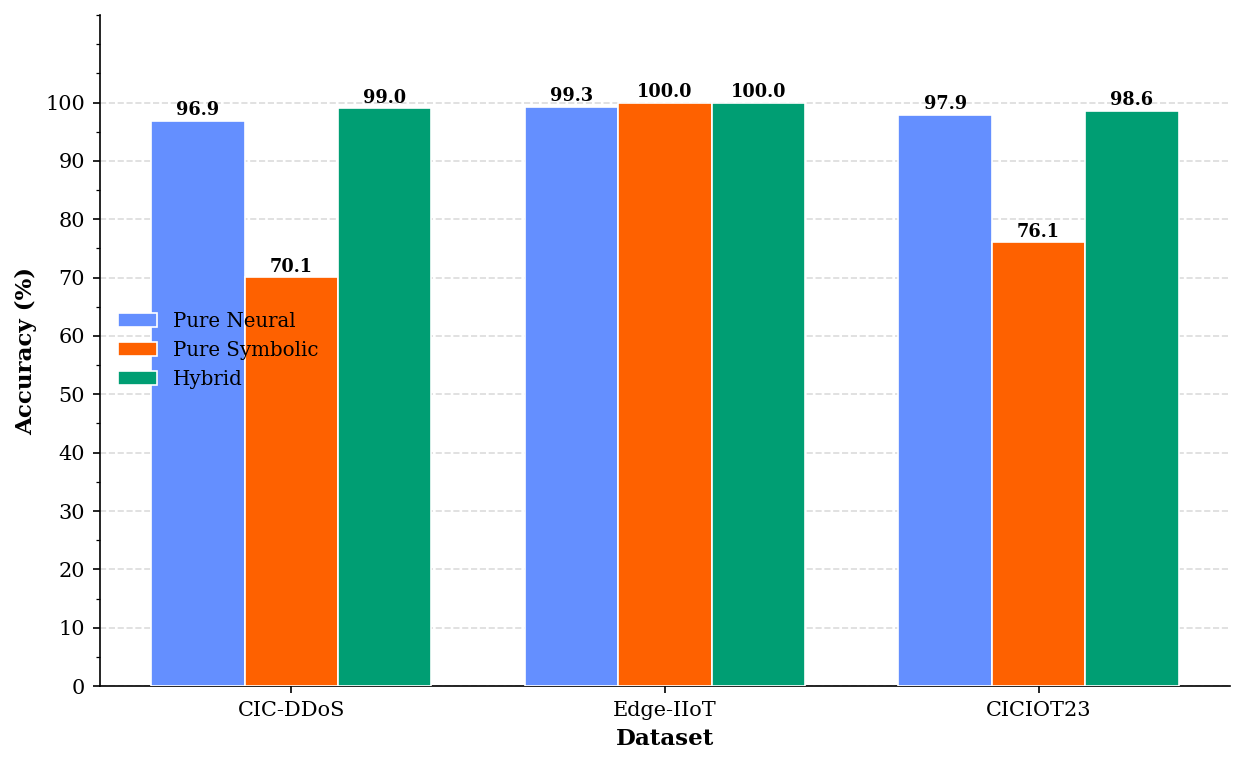

 Saved: bar_Accuracy.pdf


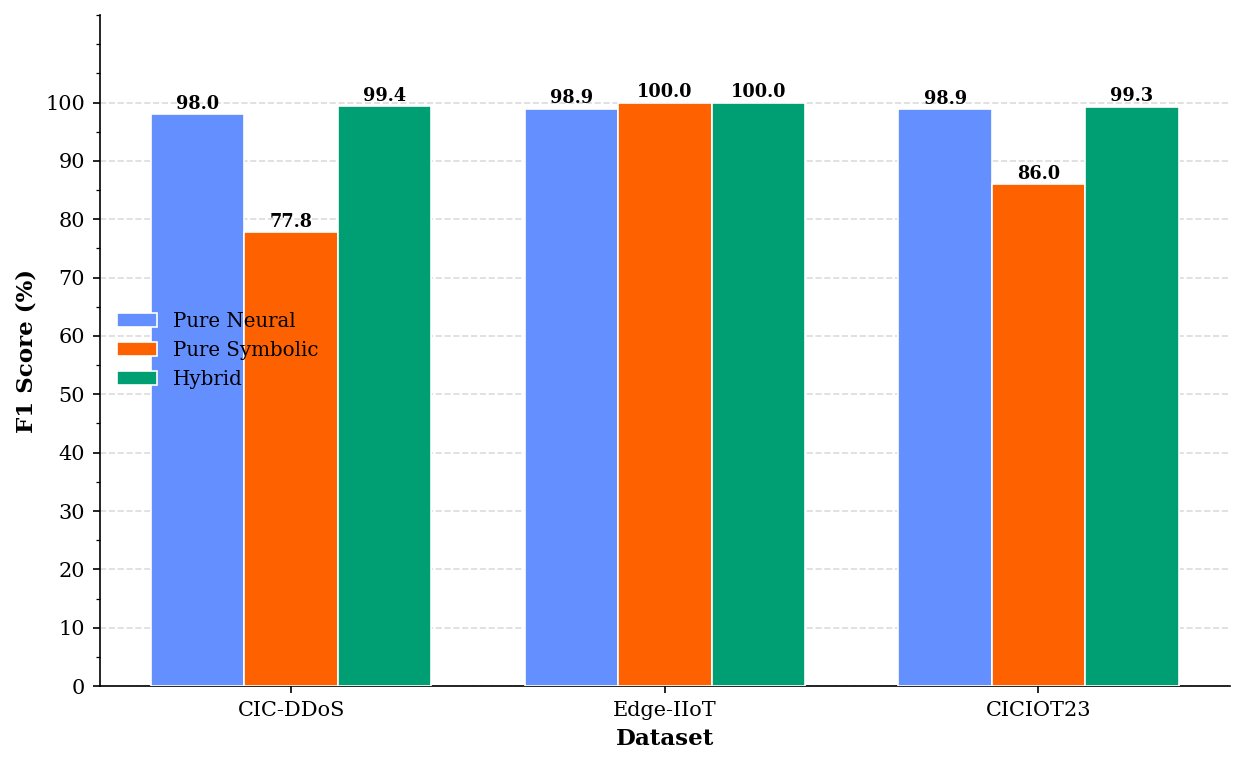

 Saved: bar_F1.pdf


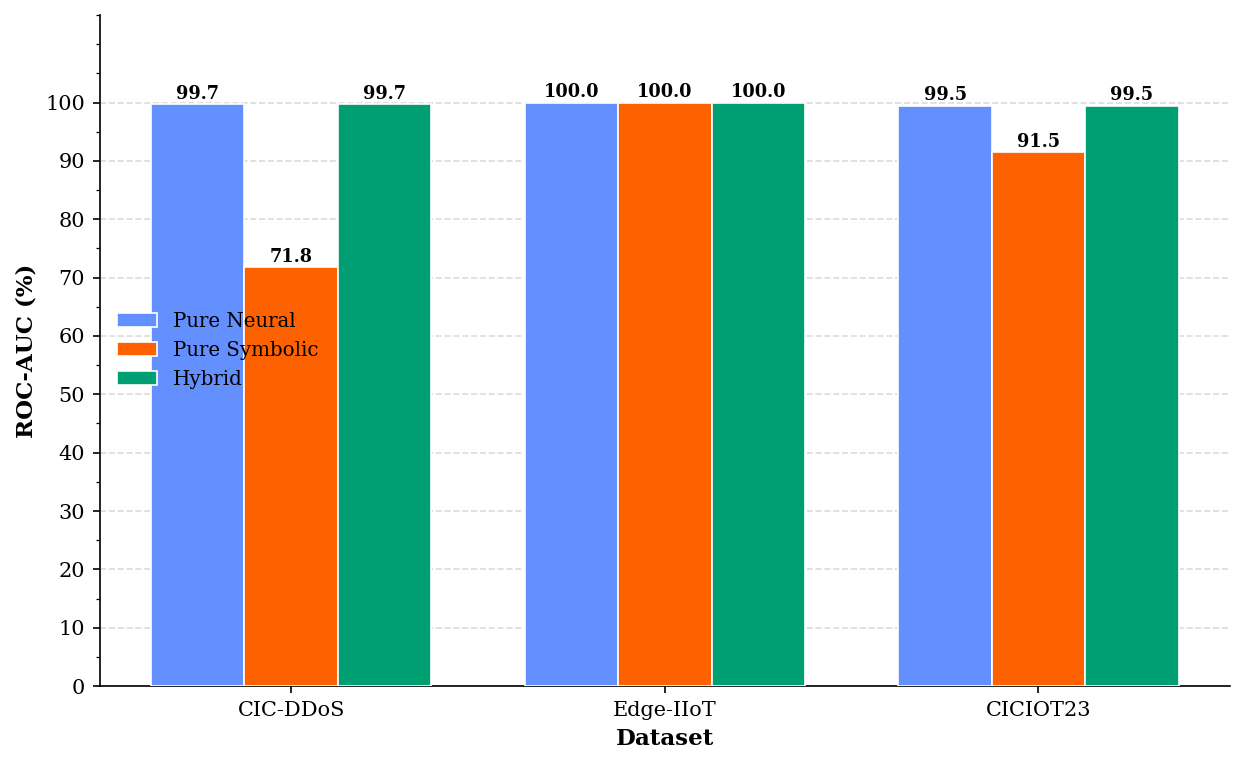

 Saved: bar_ROC-AUC.pdf


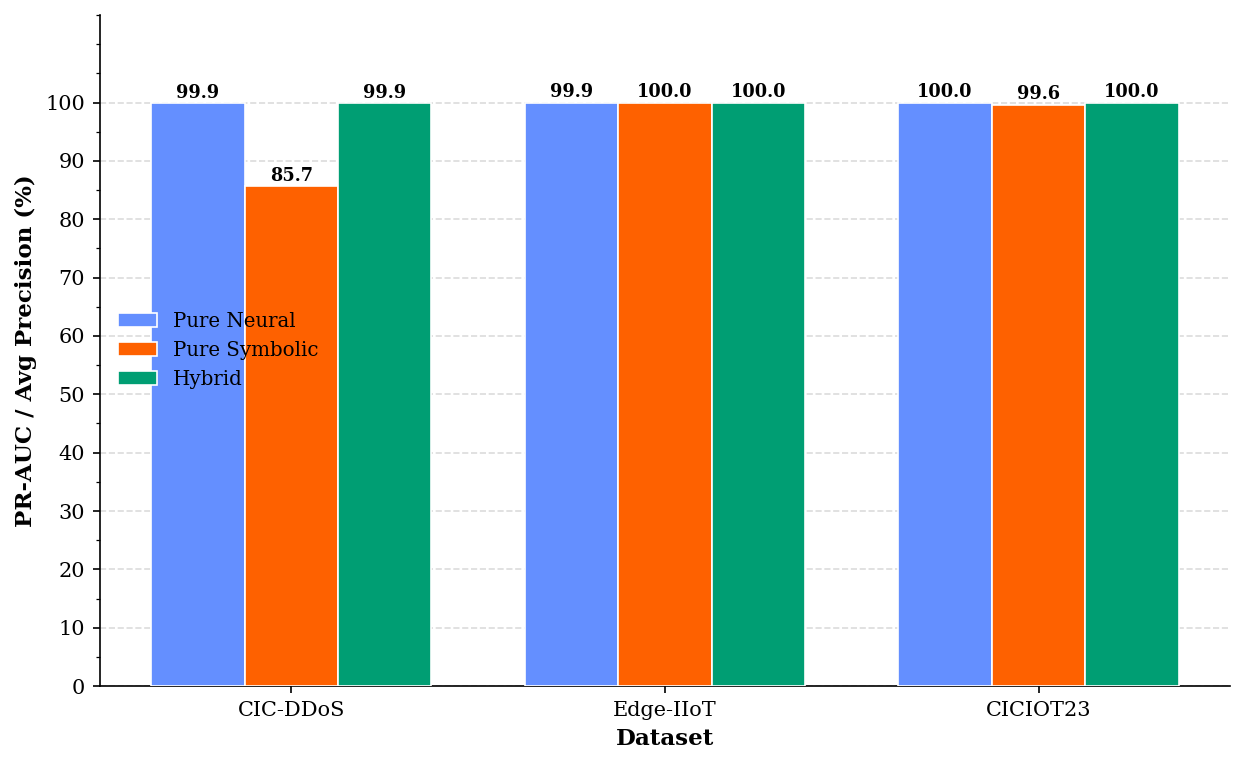

 Saved: bar_PR-AUC_AP.pdf


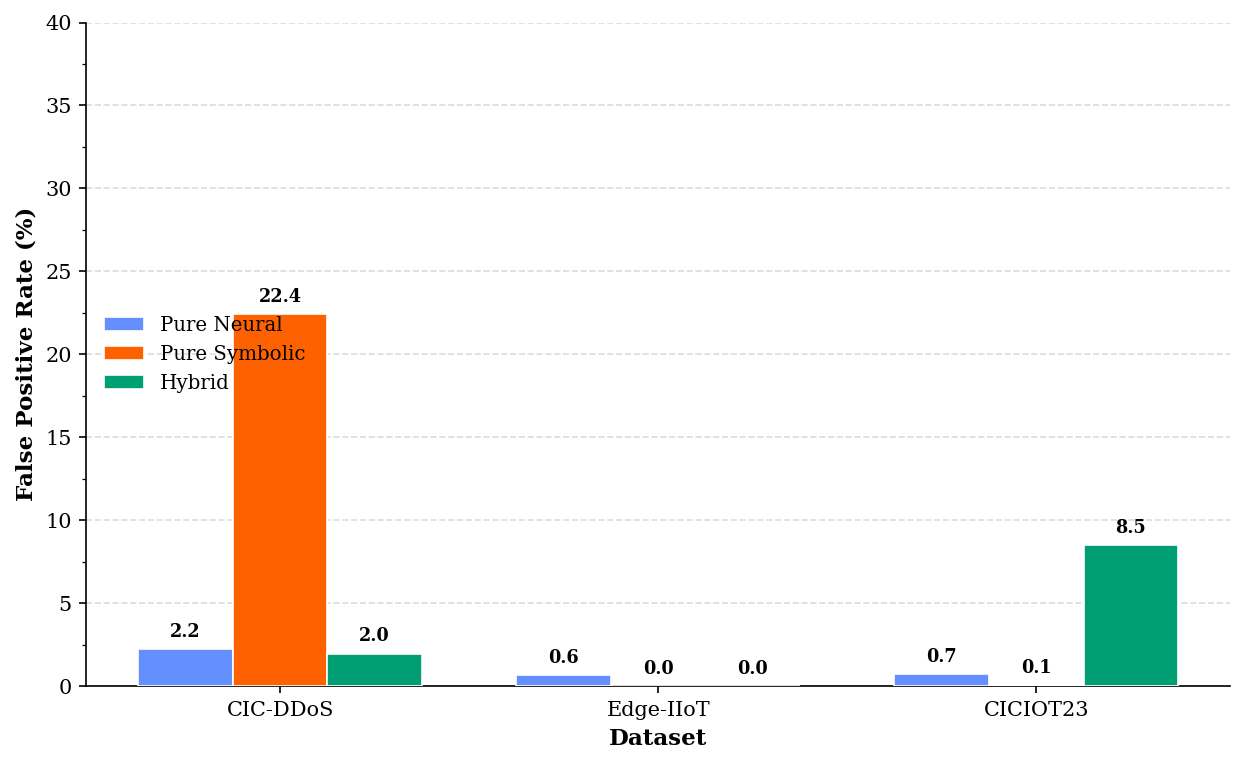

 Saved: bar_FPR.pdf


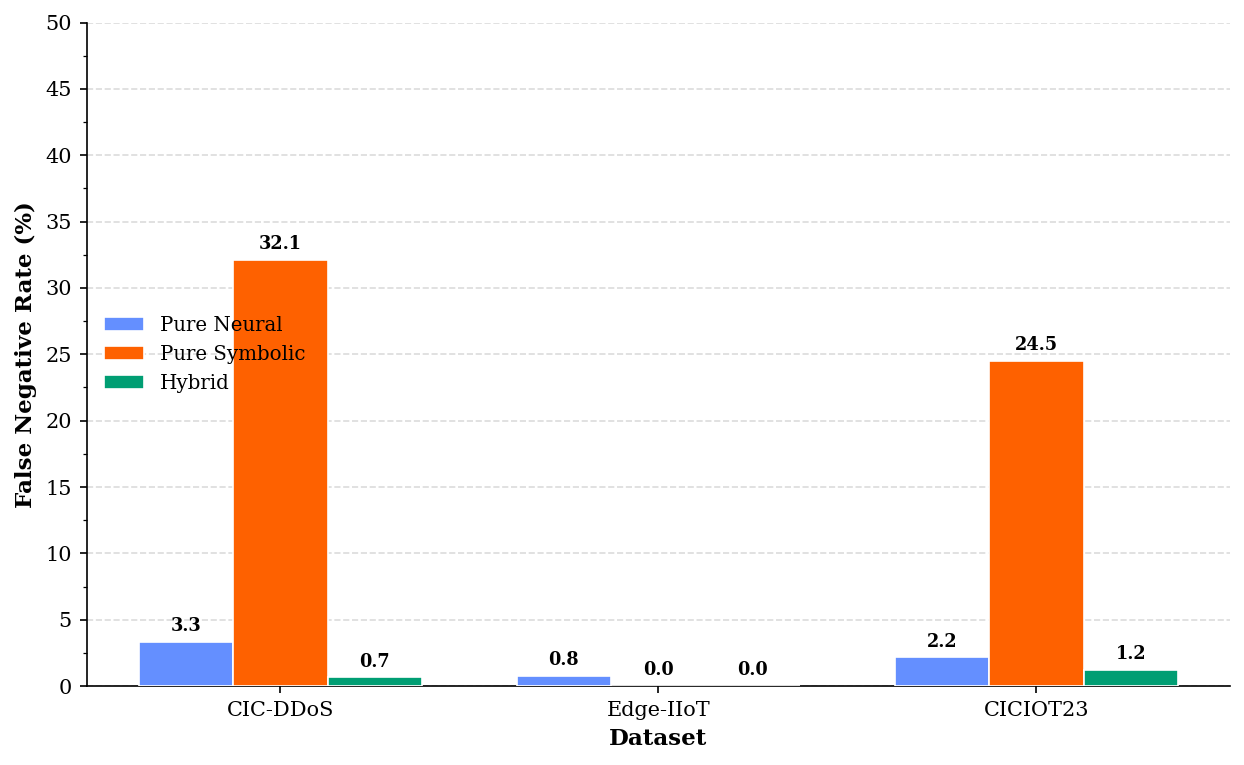

 Saved: bar_FNR.pdf

 All bar charts Created successfully!
 Folder - F:\jupyter\results


In [137]:
# CELL 11: Figures: Bar Charts
print("CELL 11: Creating Bar Charts\n")

# Style Settings
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9.5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# IBM Colour-Blind Friendly Palette
CBF = {
    'Pure Neural': '#648FFF',
    'Pure Symbolic': '#FE6100',
    'Hybrid': '#009E73',
}

# Prepare data
df_plot = df_results.copy()
df_plot['MethodGroup'] = df_plot['Method'].apply(
    lambda m: 'Hybrid' if m.startswith('Hybrid') else m
)

ds_names = ['cic_ddos', 'edge_iot', 'ciciot23']
methods = ['Pure Neural', 'Pure Symbolic', 'Hybrid']
x = np.arange(len(ds_names))
w = 0.25

# Metrics to plot — increased upper limit to make bars visually shorter
bar_metrics = [
    ('Accuracy', 'Accuracy (%)', (0, 115)),
    ('F1', 'F1 Score (%)', (0, 115)),
    ('ROC-AUC', 'ROC-AUC (%)', (0, 115)),
    ('PR-AUC (AP)', 'PR-AUC / Avg Precision (%)', (0, 115)),
    ('FPR', 'False Positive Rate (%)', (0, 40)),
    ('FNR', 'False Negative Rate (%)', (0, 50)),
]

OUT = Path("results")
OUT.mkdir(exist_ok=True)

for metric, ylabel, ylim in bar_metrics:
    fig, ax = plt.subplots(figsize=(8.4, 5.2))
   
    for i, m in enumerate(methods):
        vals = []
        for ds in ds_names:
            subset = df_plot[(df_plot['Dataset'] == ds) &
                           (df_plot['MethodGroup'] == m)]
            val = subset[metric].values[0] if not subset.empty else 0.0
            vals.append(val)
       
        bars = ax.bar(x + i * w, vals, w, label=m, color=CBF[m],
                      edgecolor='white', linewidth=0.8, zorder=3)
       
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.5 if metric in ['FPR','FNR'] else 0.25),  # reduced offset
                    f'{val:.1f}',
                    ha='center', va='bottom',
                    fontsize=8.5,
                    fontweight='bold',
                    color='black')

    # Formatting
    ax.set_xticks(x + w)
    ax.set_xticklabels(['CIC-DDoS', 'Edge-IIoT', 'CICIOT23'])
    ax.set_xlabel('Dataset', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
   
    # Taller scale = visually shorter bars
    if ylim[1] == 115:
        ax.set_ylim(0, 115)
        ax.set_yticks(range(0, 101, 10))
    else:
        ax.set_ylim(ylim)
        ax.set_yticks(range(0, int(ylim[1])+1, 5))
   
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.grid(axis='y', linestyle='--', alpha=0.45, zorder=0)
   
    # Legend stacked vertically
    ax.legend(frameon=False, loc='center left', ncol=1)

    # Saving
    clean_name = metric.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "")
    fname_pdf = OUT / f'bar_{clean_name}.pdf'
   
    plt.tight_layout()
    plt.savefig(fname_pdf, bbox_inches='tight', dpi=300)
    plt.savefig(str(fname_pdf).replace('.pdf', '.png'), bbox_inches='tight', dpi=300)
   
    plt.show()
    plt.close(fig)
   
    print(f' Saved: {fname_pdf.name}')

print('\n All bar charts Created successfully!')
print(f' Folder - {OUT.resolve()}')

CELL 12: Generating Confusion Matrices and Summary Table



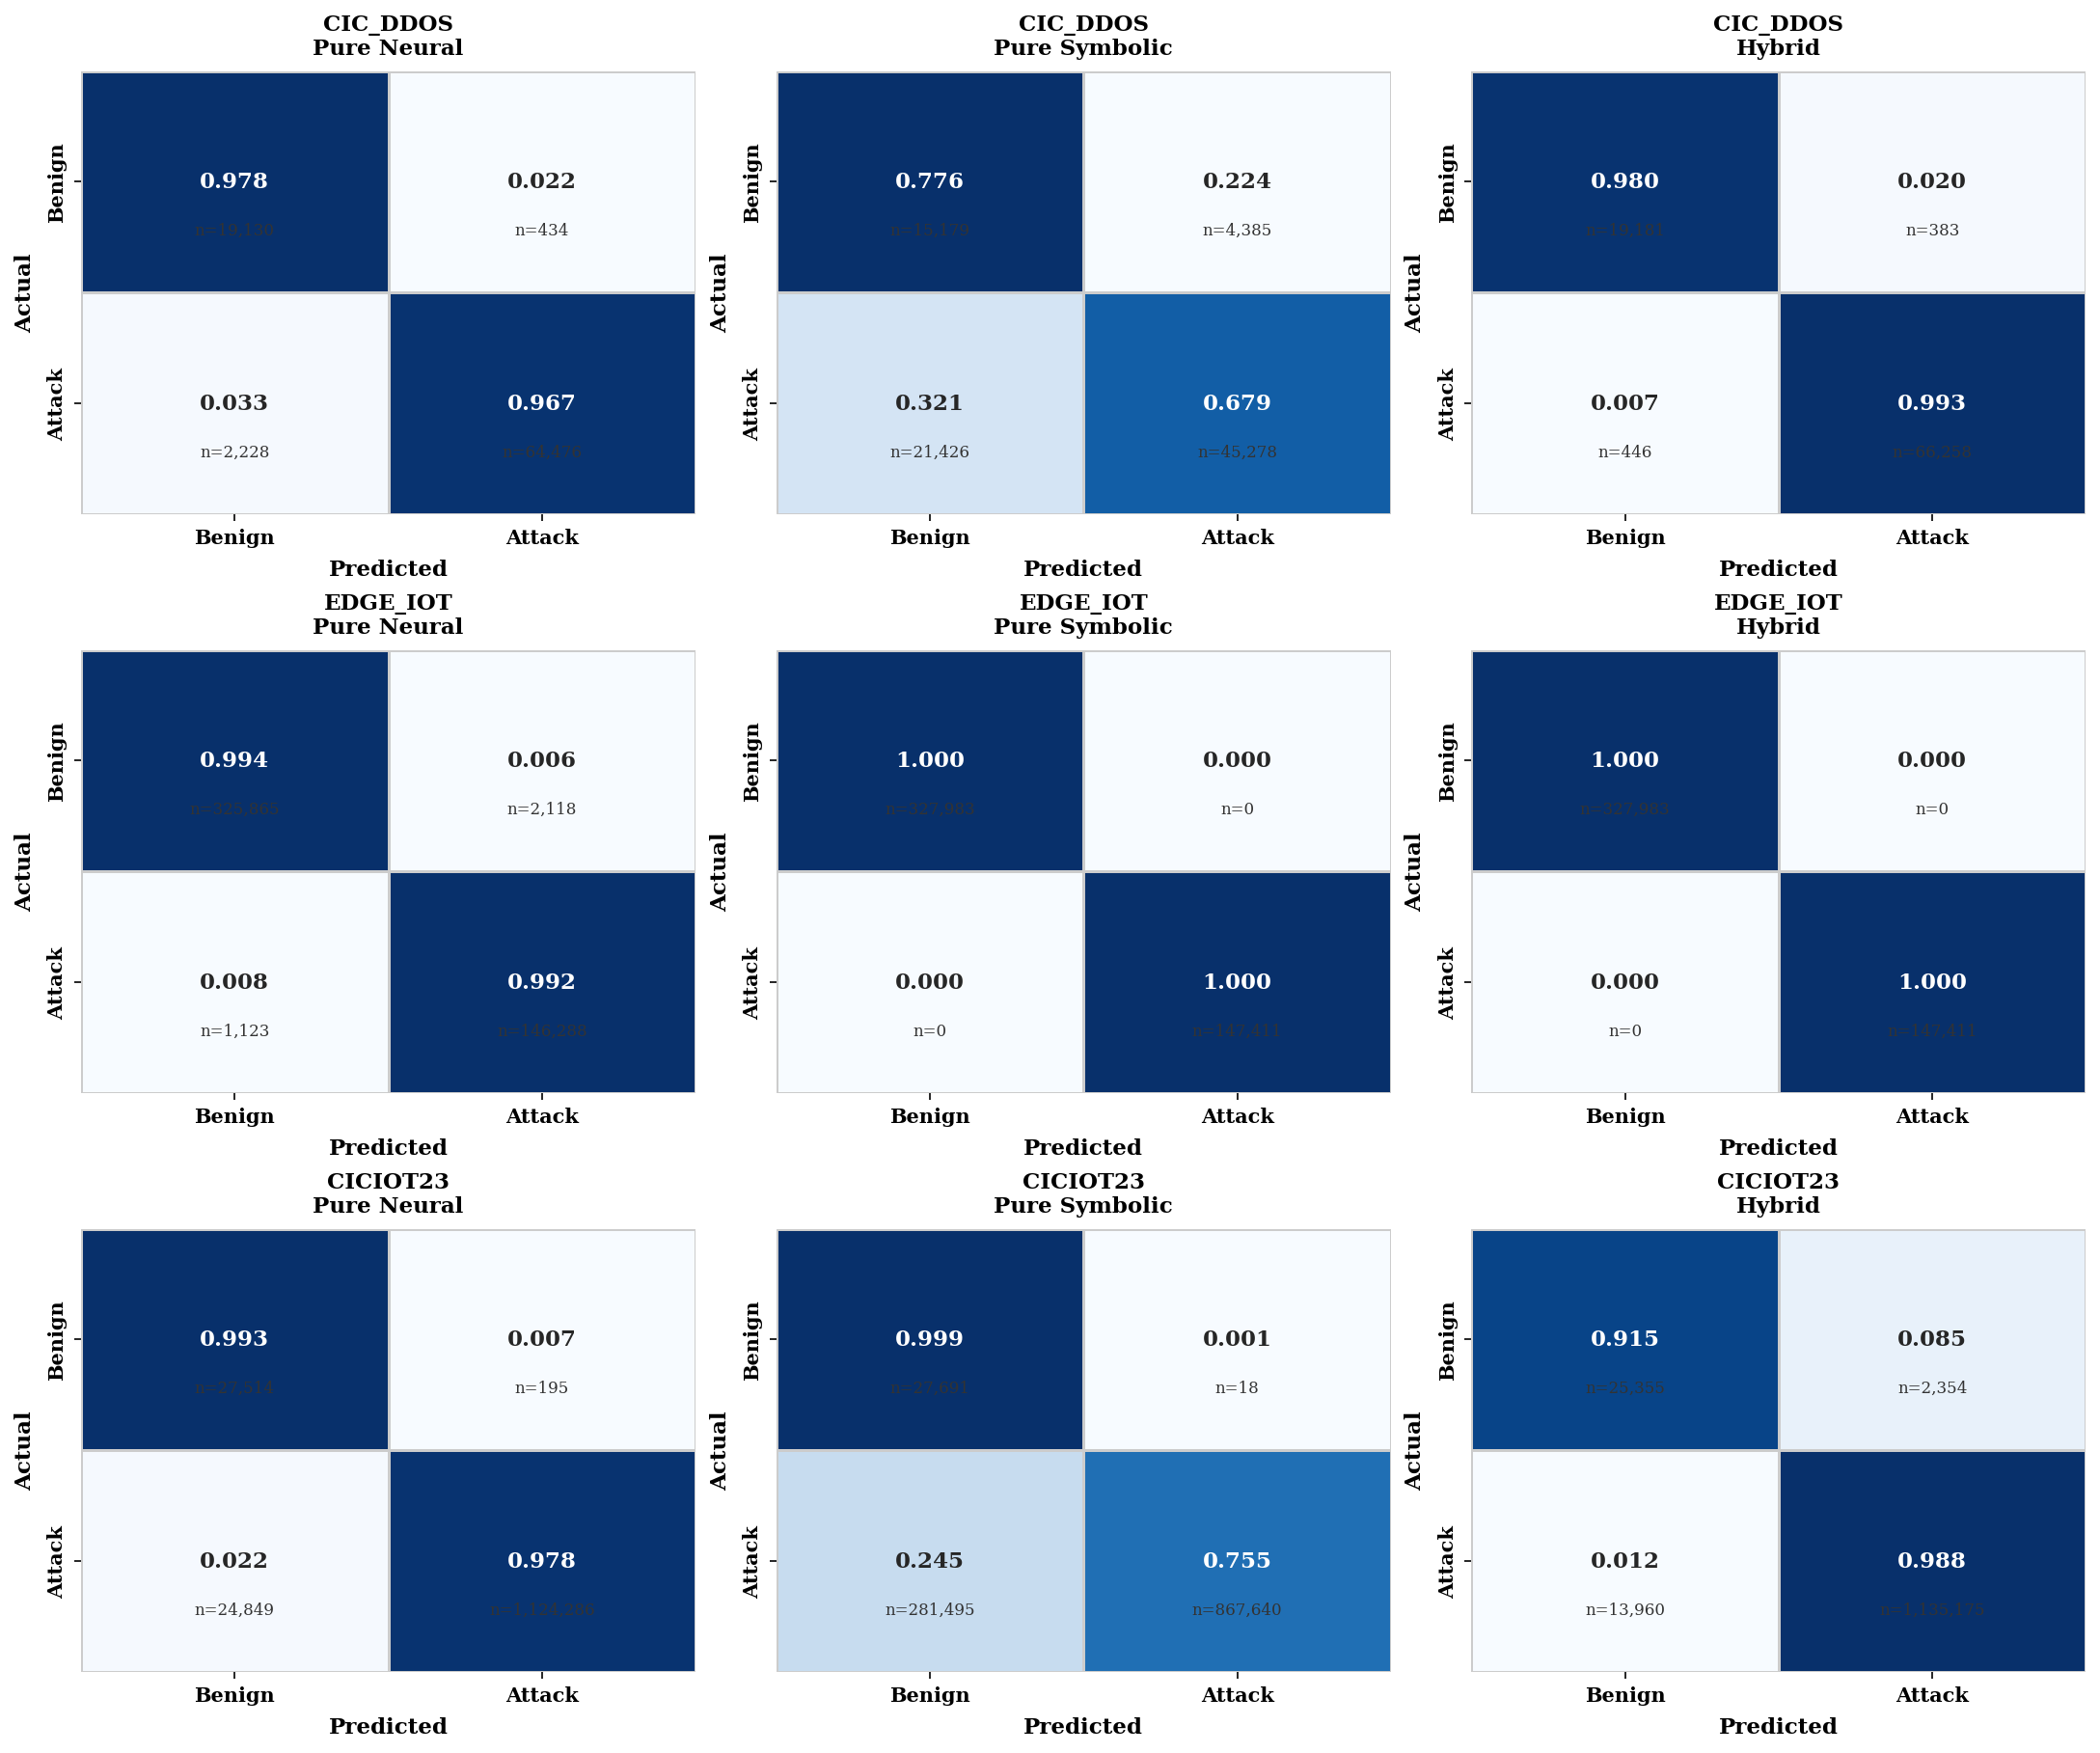

Saved confusion matrices - results\confusion_matrices.pdf
RAW CONFUSION MATRIX COUNTS (Summary Table)


,Dataset,Method,TP,TN,FP,FN,Total
0,CIC_DDOS,Pure Neural,64476,19130,434,2228,"86,268"
1,CIC_DDOS,Pure Symbolic,45278,15179,4385,21426,"86,268"
2,CIC_DDOS,Hybrid,66258,19181,383,446,"86,268"
3,EDGE_IOT,Pure Neural,146288,325865,2118,1123,"475,394"
4,EDGE_IOT,Pure Symbolic,147411,327983,0,0,"475,394"
5,EDGE_IOT,Hybrid,147411,327983,0,0,"475,394"
6,CICIOT23,Pure Neural,1124286,27514,195,24849,"1,176,844"
7,CICIOT23,Pure Symbolic,867640,27691,18,281495,"1,176,844"
8,CICIOT23,Hybrid,1135175,25355,2354,13960,"1,176,844"



Saved summary table - results/confusion_matrix_summary.csv


In [119]:
# CELL 12: Figures (Part 2): Confusion Matrices and  Summary Table

print("CELL 12: Generating Confusion Matrices and Summary Table\n")

ds_list = list(neural_probs.keys())
n_ds    = len(ds_list)
n_meth  = 3

fig, axes = plt.subplots(n_ds, n_meth,
                          figsize=(4.8 * n_meth, 4.0 * n_ds),
                          constrained_layout=True)

if n_ds == 1:
    axes = axes[np.newaxis, :]

cm_summary = []

for i, ds in enumerate(ds_list):
    n_te = neural_probs[ds]['test']
    s_te = symbolic_probs[ds]['test']
    y_te = y_splits[ds]['test']
    α    = alpha_opt[ds]
    th   = thresh_opt[ds]
    h_te = α * n_te + (1 - α) * s_te

    method_probs = [
        ('Pure Neural',   n_te, 0.5),
        ('Pure Symbolic', s_te, 0.5),
        ('Hybrid',        h_te, th),
    ]

    for j, (mname, probs, threshold) in enumerate(method_probs):
        pred = (probs >= threshold).astype(int)
        cm   = confusion_matrix(y_te, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        cm_summary.append({
            'Dataset': ds.upper(),
            'Method': mname,
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'Total': len(y_te)
        })

        # Row-normalised confusion matrix
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax = axes[i, j]
        sns.heatmap(
            cm_norm, annot=True, fmt='.3f', cmap='Blues', cbar=False,
            ax=ax, linewidths=0.5, linecolor='#cccccc',
            annot_kws={'size': 11, 'weight': 'bold'},
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack']
        )

        # Raw counts overlay
        for (r, c), v in np.ndenumerate(cm):
            ax.text(c + 0.5, r + 0.72, f'n={v:,}',
                    ha='center', va='center', fontsize=8, color='#333333')

        ax.set_title(f'{ds.upper()}\n{mname}', fontsize=11, pad=8, fontweight='bold')
        ax.set_xlabel('Predicted', labelpad=6, fontweight='bold')
        ax.set_ylabel('Actual',    labelpad=6, fontweight='bold')
        ax.set_xticklabels(['Benign', 'Attack'], fontweight='bold')
        ax.set_yticklabels(['Benign', 'Attack'], fontweight='bold')

# Saving the figure
fname = OUT / 'confusion_matrices.pdf'
fig.savefig(fname, bbox_inches='tight', dpi=300)
fig.savefig(str(fname).replace('.pdf', '.png'), bbox_inches='tight', dpi=300)
plt.show()
plt.close(fig)

print(f'Saved confusion matrices - {fname}')


# SUMMARY TABLE 
print("RAW CONFUSION MATRIX COUNTS (Summary Table)")

summary_df = pd.DataFrame(cm_summary)

# column order
summary_df = summary_df[['Dataset', 'Method', 'TP', 'TN', 'FP', 'FN', 'Total']]

# Display
display(summary_df.style.set_caption("Raw Counts from Confusion Matrices")
                    .format({'Total': '{:,}'})
                    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}]))

# Also save to CSV
summary_df.to_csv(OUT / 'confusion_matrix_summary.csv', index=False)
print(f"\nSaved summary table - {OUT}/confusion_matrix_summary.csv")

CELL 13: Figures; ROC & PR Curves



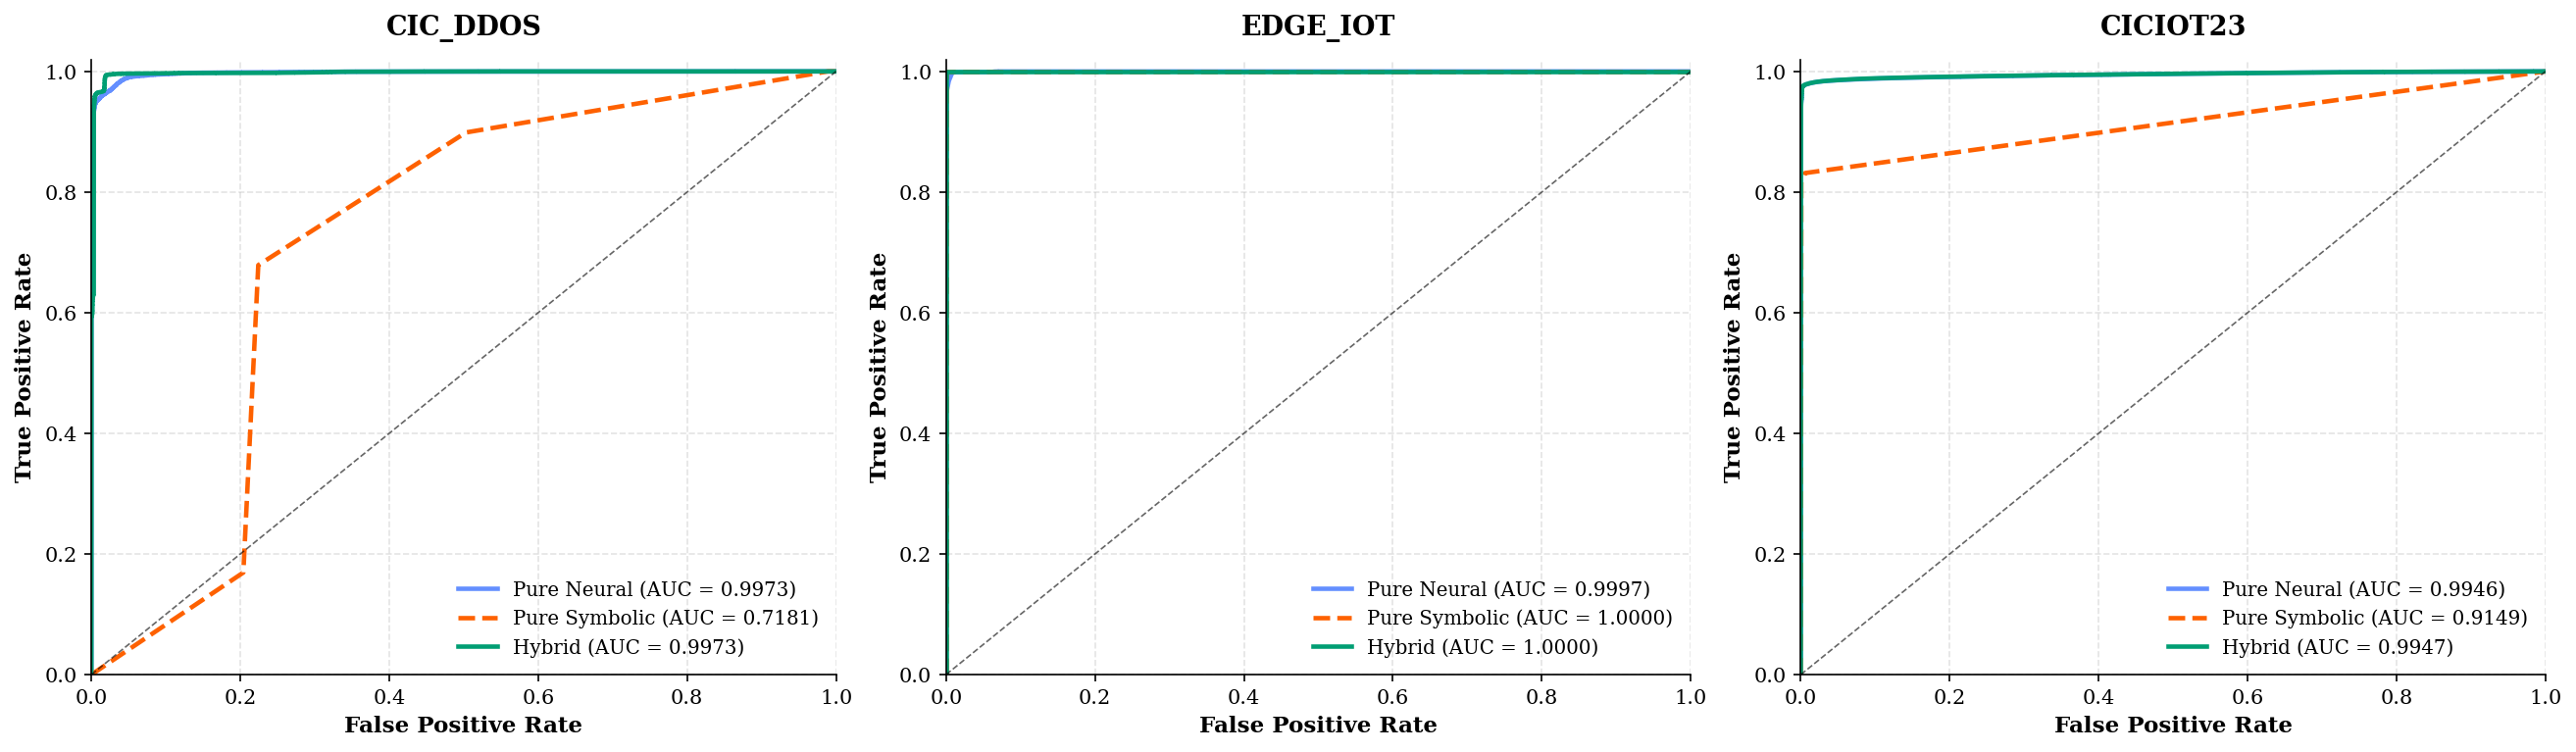

   Saved: roc_curves.pdf


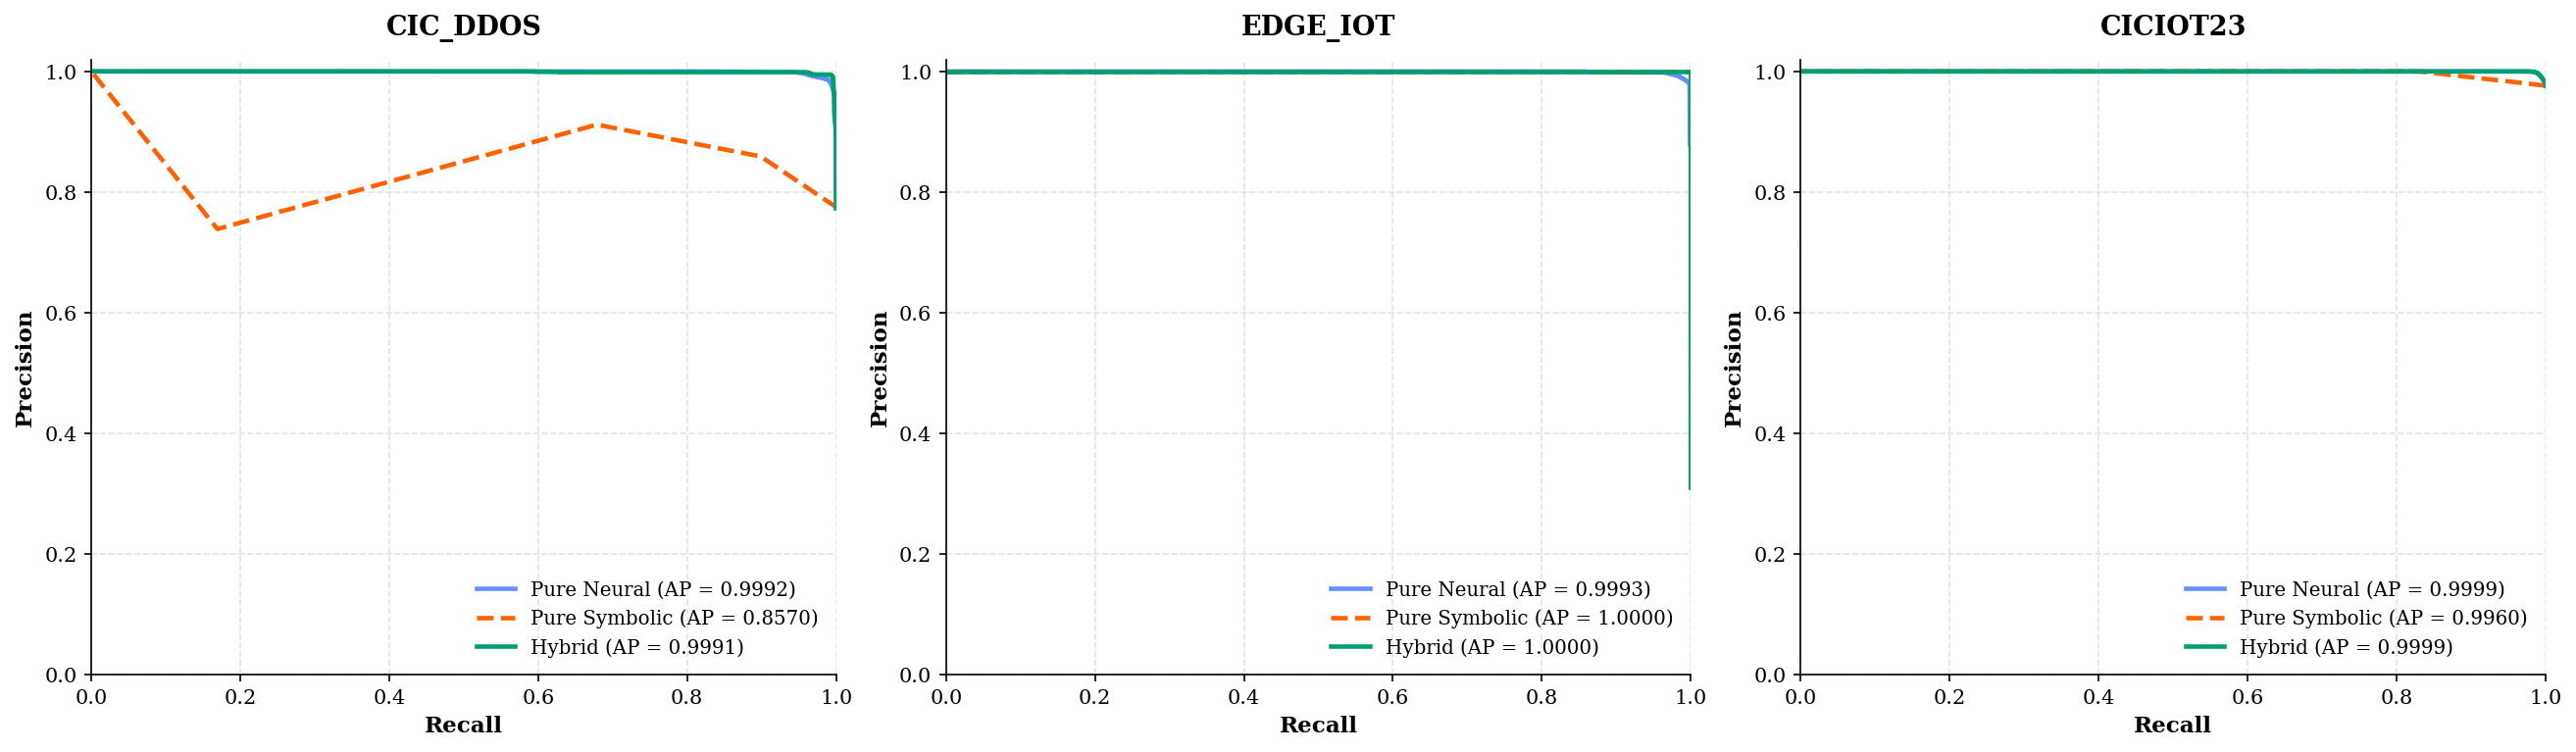

   Saved: pr_curves.pdf

 ROC and PR curves createdsuccessfully!


In [120]:
# CELL 13: Figures (Part 3): ROC & PR Curves
print("CELL 13: Figures; ROC & PR Curves\n")

# IBM Colour-Blind Friendly Palette
CBF = {
    'Pure Neural':  '#648FFF',
    'Pure Symbolic': '#FE6100',
    'Hybrid':       '#009E73',
}

line_styles = {
    'Pure Neural':   ('-',  CBF['Pure Neural']),
    'Pure Symbolic': ('--', CBF['Pure Symbolic']),
    'Hybrid':        ('-',  CBF['Hybrid']),
}

ds_list = list(neural_probs.keys())

for curve_type in ('roc', 'pr'):
    fig, axes = plt.subplots(1, len(ds_list),
                              figsize=(5.8 * len(ds_list), 5.0),
                              constrained_layout=True)
    
    if len(ds_list) == 1:
        axes = [axes]

    for idx, ds in enumerate(ds_list):
        ax = axes[idx]
        y_te = y_splits[ds]['test']
        n_te = neural_probs[ds]['test']
        s_te = symbolic_probs[ds]['test']
        α    = alpha_opt[ds]
        h_te = α * n_te + (1 - α) * s_te

        all_methods = [
            ('Pure Neural',   n_te),
            ('Pure Symbolic', s_te),
            ('Hybrid',        h_te)
        ]

        for mname, probs in all_methods:
            ls, color = line_styles[mname]
            try:
                if curve_type == 'roc':
                    fpr, tpr, _ = roc_curve(y_te, probs)
                    auc = roc_auc_score(y_te, probs)
                    ax.plot(fpr, tpr, ls, color=color, lw=2.2,
                            label=f'{mname} (AUC = {auc:.4f})')
                else:  # PR curve
                    prec, rec, _ = precision_recall_curve(y_te, probs)
                    ap = average_precision_score(y_te, probs)
                    ax.plot(rec, prec, ls, color=color, lw=2.2,
                            label=f'{mname} (AP = {ap:.4f})')
            except Exception as e:
                print(f'  Warning: {ds} {mname} curve failed - {e}')

        ax.set_title(ds.upper(), fontsize=13, fontweight='bold', pad=12)
        
        if curve_type == 'roc':
            ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.6)
            ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
            ax.set_ylabel('True Positive Rate',  fontsize=11, fontweight='bold')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1.02])
        else:
            ax.set_xlabel('Recall',    fontsize=11, fontweight='bold')
            ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1.02])

        ax.grid(True, linestyle='--', alpha=0.35)
        ax.legend(frameon=False, fontsize=9.5, loc='lower right')

    # Saving
    fname = OUT / f'{curve_type}_curves.pdf'
    fig.savefig(fname, bbox_inches='tight', dpi=300)
    fig.savefig(str(fname).replace('.pdf', '.png'), bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close(fig)
    
    print(f'   Saved: {fname.name}')

print('\n ROC and PR curves createdsuccessfully!')

CELL 14: Creating Training Curves 



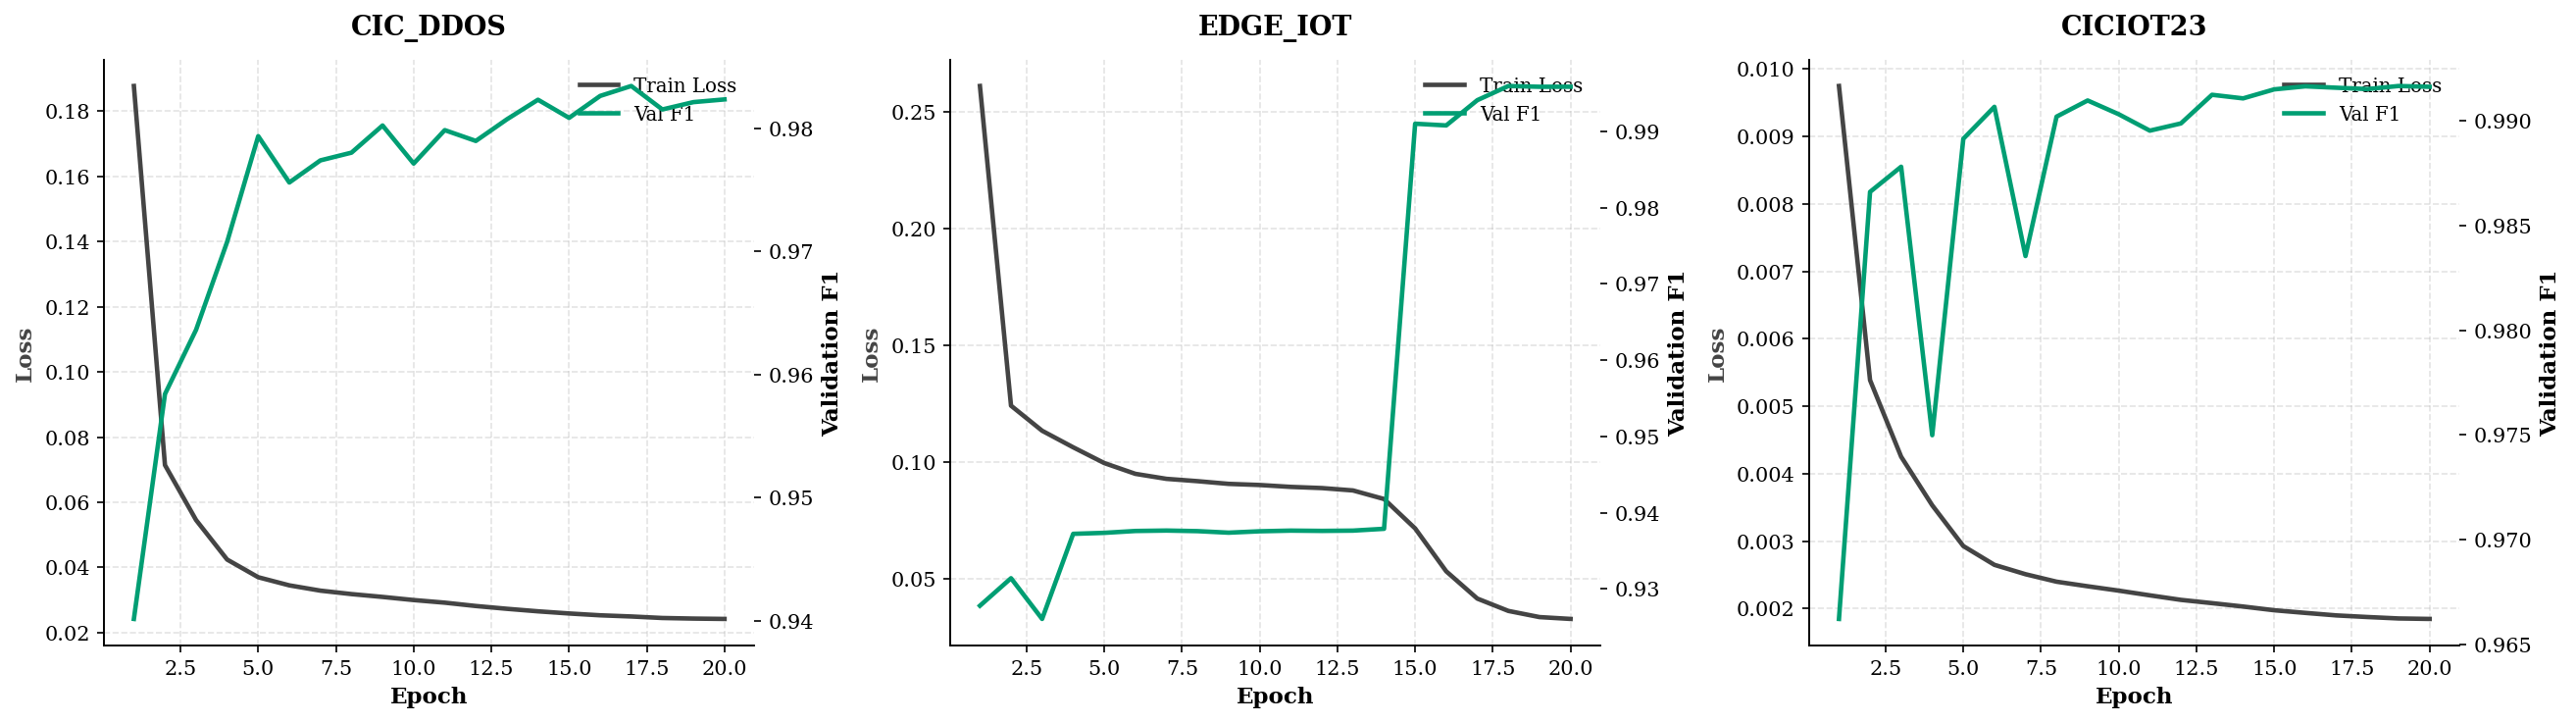

Saved: results\training_curves.pdf


In [134]:
# CELL 14: Figures (Part 4): Training Curves
print("CELL 14: Creating Training Curves \n")

CBF = {
    'Pure Neural': '#648FFF',
    'Pure Symbolic': '#FE6100',
    'Hybrid': '#009E73',
}

ds_list = list(neural_probs.keys()) if 'neural_probs' in globals() else ['cic_ddos', 'edge_iot', 'ciciot23']

fig, axes = plt.subplots(1, len(ds_list),
                          figsize=(5.8 * len(ds_list), 4.8),
                          constrained_layout=True)

if len(ds_list) == 1:
    axes = [axes]

for ax, ds in zip(axes, ds_list):
    # Safely getting history
    hist = train_histories.get(ds, []) if 'train_histories' in globals() else []
    
    if not hist:
        # placeholder
        ax.text(0.5, 0.5, f'Training history not recorded\nfor {ds.upper()}',
                ha='center', va='center', fontsize=12, transform=ax.transAxes,
                fontweight='bold', color='#666666')
        ax.set_title(ds.upper(), fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        continue
    
    # If history exists, plot it
    epochs = [h.get('epoch', i+1) for i, h in enumerate(hist)]
    loss = [h.get('loss', 0) for h in hist]
    val_f1 = [h.get('val_f1', 0) for h in hist]
    
    ax2 = ax.twinx()
    ax.plot(epochs, loss, color='#444444', lw=2.2, label='Train Loss')
    ax2.plot(epochs, val_f1, color=CBF['Hybrid'], lw=2.2, label='Val F1')
    
    ax.set_title(ds.upper(), fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=11, fontweight='bold', color='#444444')
    ax2.set_ylabel('Validation F1', fontsize=11, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.35)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              frameon=False, fontsize=9.5, loc='upper right')

# Saving
fname = OUT / 'training_curves.pdf'
fig.savefig(fname, bbox_inches='tight', dpi=300)
fig.savefig(str(fname).replace('.pdf', '.png'), bbox_inches='tight', dpi=300)

plt.show()
plt.close(fig)

print(f'Saved: {fname}')

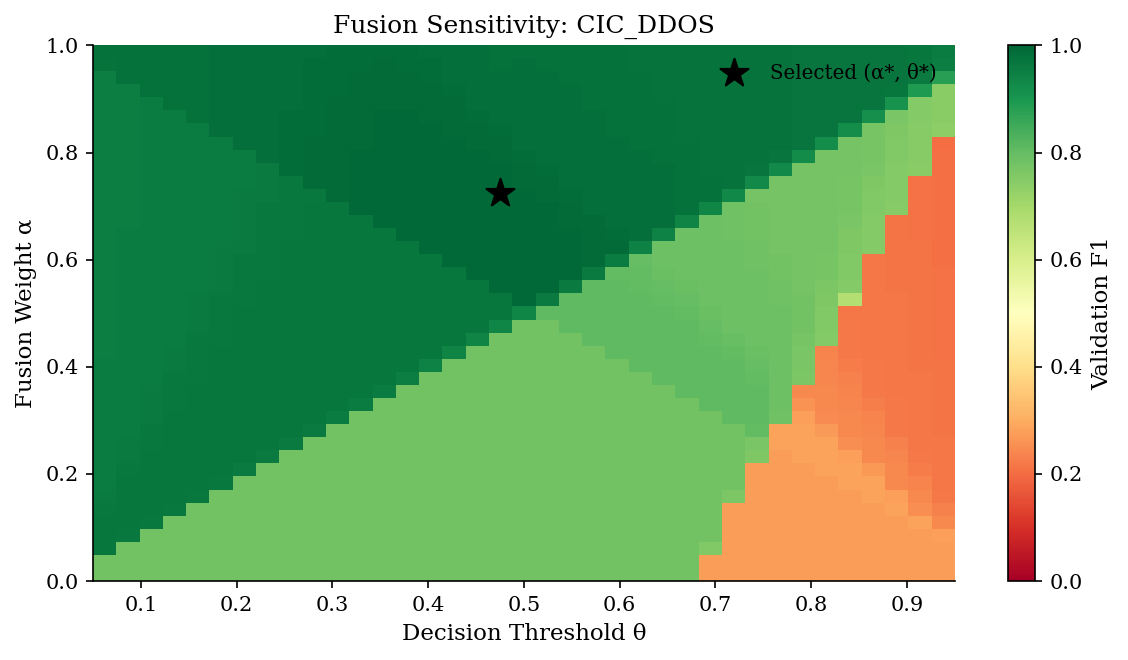

  Saved: results\alpha_heatmap_cic_ddos.pdf


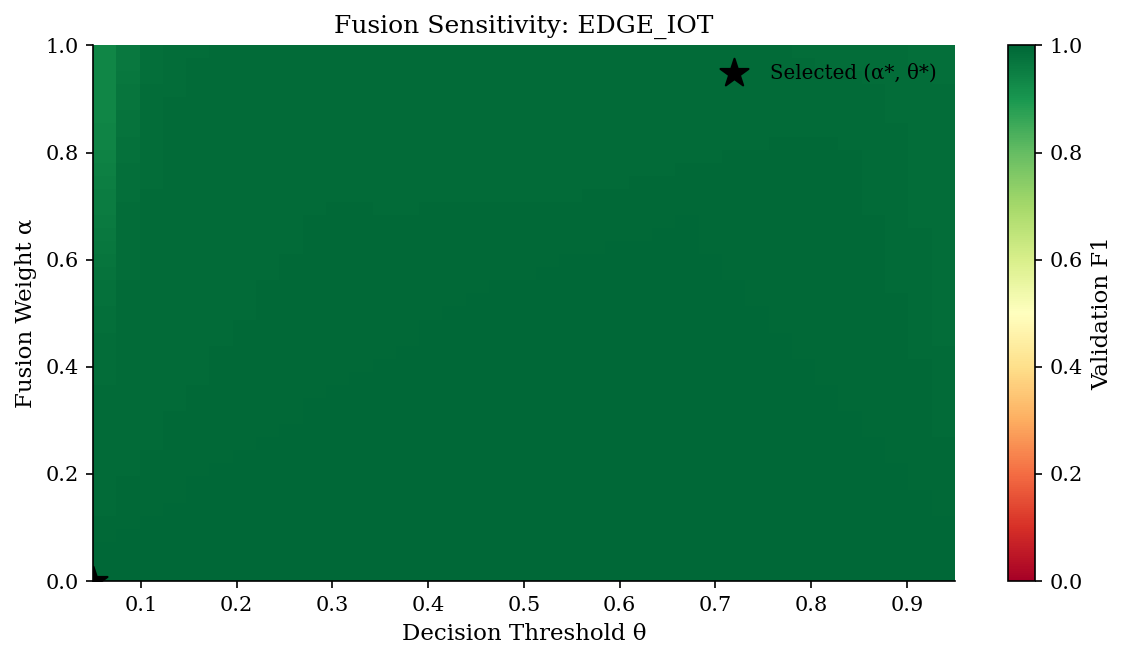

  Saved: results\alpha_heatmap_edge_iot.pdf


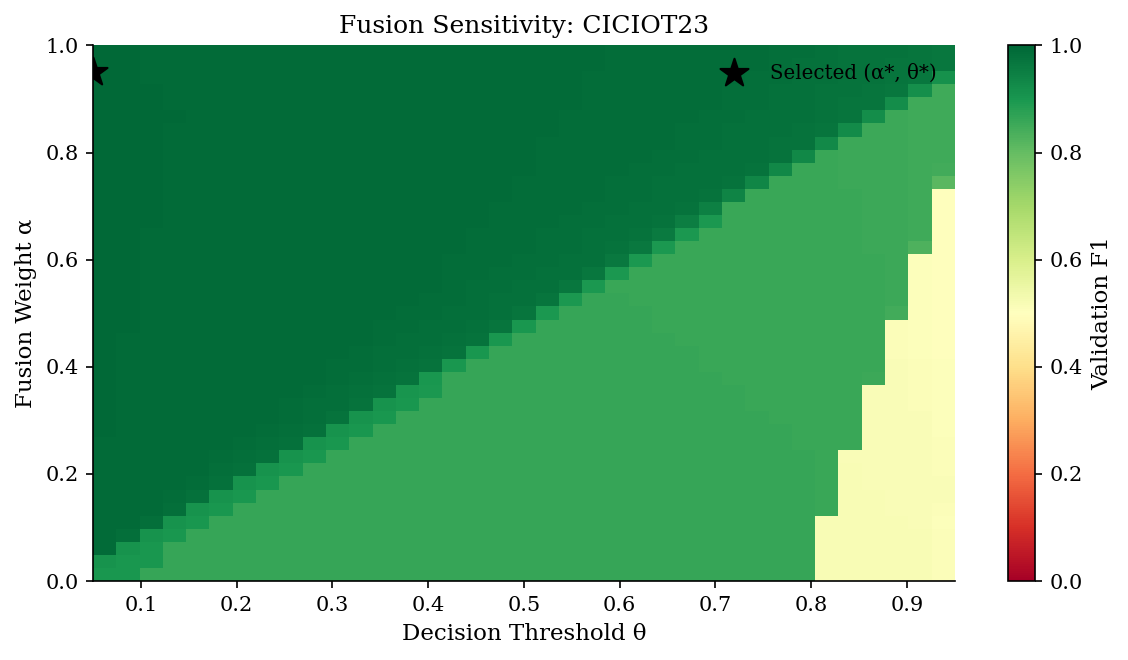

  Saved: results\alpha_heatmap_ciciot23.pdf


In [122]:
# CELL 15: Figures (Part 5): Alpha Sensitivity Heatmap

# Shows how classification F1 changes across α ∈ [0,1] and threshold ∈ [0.05, 0.95].
# Confirms the robustness of the selected fusion weight, if the optimal region
# is wide, the system is not fragile to small α perturbations (important for
# deployment where α may need slight tuning per site).

for ds in ds_list:
    n_v = neural_probs[ds]['val']
    s_v = symbolic_probs[ds]['val']
    y_v = y_splits[ds]['val']

    # (n_alphas × n_thresholds) F1 grid
    H   = np.outer(ALPHAS, n_v) + np.outer(1.0 - ALPHAS, s_v)  # (A, N)
    grid = np.zeros((len(ALPHAS), len(THRESHOLDS)))

    for ai in range(len(ALPHAS)):
        for ti, th in enumerate(THRESHOLDS):
            pred = (H[ai] >= th).astype(np.int8)
            if 0 < pred.sum() < len(pred):
                grid[ai, ti] = f1_score(y_v, pred, zero_division=0)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(grid, aspect='auto', origin='lower',
                   extent=[THRESHOLDS[0], THRESHOLDS[-1], ALPHAS[0], ALPHAS[-1]],
                   cmap='RdYlGn', vmin=0, vmax=1)

    # mark optimal point
    ax.scatter([thresh_opt[ds]], [alpha_opt[ds]], marker='*',
               s=200, c='black', zorder=5, label='Selected (α*, θ*)')

    plt.colorbar(im, ax=ax, label='Validation F1')
    ax.set_xlabel('Decision Threshold θ')
    ax.set_ylabel('Fusion Weight α')
    ax.set_title(f'Fusion Sensitivity: {ds.upper()}')
    ax.legend(frameon=False)
    fname = OUT / f'alpha_heatmap_{ds}.pdf'
    fig.tight_layout()
    fig.savefig(fname, bbox_inches='tight')
    fig.savefig(str(fname).replace('.pdf', '.png'), bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'  Saved: {fname}')

In [123]:
# CELL 16: Figures (Part 4): Inference Latency & Throughput Benchmark
print("CELL 16: Inference Latency & Throughput Benchmark\n")

# Settings
WARMUP_RUNS   = 200
MEASURE_RUNS  = 1000
BENCH_BATCH   = 256

# Using the same datasets
ds_list = list(trained_models.keys()) if 'trained_models' in globals() else ['cic_ddos', 'edge_iot', 'ciciot23']

bench_results = []

for ds in ds_list:
    print(f'[{ds.upper()}]')
    
    model = trained_models[ds]
    model.eval()
    device = next(model.parameters()).device


    X_te = datasets[ds]['X_test']
    y_te = datasets[ds]['y_test']
    bench_ds = SlidingWindowDataset(X_te, y_te, SEQ_LEN)   # ← Fixed class name

    n_avail = len(bench_ds)
    if n_avail < WARMUP_RUNS + MEASURE_RUNS:
        print(f'   Only {n_avail:,} windows available; adjusting runs')
        _warmup = min(50, n_avail // 4)
        _measure = min(300, n_avail - _warmup)
    else:
        _warmup, _measure = WARMUP_RUNS, MEASURE_RUNS

    # Model size
    n_params = sum(p.numel() for p in model.parameters())
    model_mb = n_params * 4 / (1024 ** 2)

    # Warmup 
    with torch.no_grad():
        for i in range(_warmup):
            x, _ = bench_ds[i % n_avail]
            _ = model(x.unsqueeze(0).to(device))

    # Single-window latency (per-packet decision)
    latencies_us = []
    with torch.no_grad():
        for i in range(_measure):
            x, _ = bench_ds[(i + _warmup) % n_avail]
            x = x.unsqueeze(0).to(device)
            t0 = time.perf_counter()
            _ = model(x)
            latencies_us.append((time.perf_counter() - t0) * 1_000_000)

    lat_arr = np.array(latencies_us)

    # Batch throughput (flow-level collector)
    loader = DataLoader(bench_ds, batch_size=BENCH_BATCH,
                        shuffle=False, num_workers=0, pin_memory=False)

    batch_times = []
    with torch.no_grad():
        for bi, (xb, _) in enumerate(loader):
            if bi < 5: continue    # skip initial warmup batches
            xb = xb.to(device)
            t0 = time.perf_counter()
            _ = model(xb)
            elapsed = time.perf_counter() - t0
            batch_times.append((elapsed, len(xb)))
            if len(batch_times) >= 30: break   # enough samples

    total_samples = sum(b[1] for b in batch_times)
    total_time = sum(b[0] for b in batch_times)
    thr_wps = total_samples / total_time if total_time > 0 else 0.0

    # Store results
    row = {
        'Dataset'          : ds,
        'Params'           : n_params,
        'Model MB'         : round(model_mb, 3),
        'Lat p50 (μs)'     : round(np.percentile(lat_arr, 50), 2),
        'Lat p95 (μs)'     : round(np.percentile(lat_arr, 95), 2),
        'Lat p99 (μs)'     : round(np.percentile(lat_arr, 99), 2),
        'Lat Mean (μs)'    : round(lat_arr.mean(), 2),
        'Lat Std (μs)'     : round(lat_arr.std(),  2),
        'Throughput (w/s)' : round(thr_wps, 0),
    }
    bench_results.append(row)

    # Print summary
    print(f'  Model size      : {n_params:,} params ({model_mb:.2f} MB)')
    print(f'  Latency p50/p95/p99 : {row["Lat p50 (μs)"]}/{row["Lat p95 (μs)"]}/{row["Lat p99 (μs)"]} μs')
    print(f'  Throughput      : {thr_wps:,.0f} windows/s\n')

# Final table
df_bench = pd.DataFrame(bench_results)
display_cols = ['Dataset', 'Model MB', 'Lat p50 (μs)', 'Lat p95 (μs)', 
                'Lat p99 (μs)', 'Throughput (w/s)']

print("INFERENCE BENCHMARK SUMMARY")
print(df_bench[display_cols].to_string(index=False))

# Save
df_bench.to_csv(OUT / 'inference_benchmark.csv', index=False)
print(f'\nSaved - {OUT}/inference_benchmark.csv')

CELL 16: Inference Latency & Throughput Benchmark

[CIC_DDOS]
  Model size      : 8,197 params (0.03 MB)
  Latency p50/p95/p99 : 438.65/462.13/547.88 μs
  Throughput      : 214,018 windows/s

[EDGE_IOT]
  Model size      : 6,531 params (0.02 MB)
  Latency p50/p95/p99 : 437.75/466.02/553.14 μs
  Throughput      : 241,633 windows/s

[CICIOT23]
  Model size      : 6,825 params (0.03 MB)
  Latency p50/p95/p99 : 437.8/481.71/546.09 μs
  Throughput      : 231,493 windows/s

INFERENCE BENCHMARK SUMMARY
 Dataset  Model MB  Lat p50 (μs)  Lat p95 (μs)  Lat p99 (μs)  Throughput (w/s)
cic_ddos     0.031        438.65        462.13        547.88          214018.0
edge_iot     0.025        437.75        466.02        553.14          241633.0
ciciot23     0.026        437.80        481.71        546.09          231493.0

Saved - results/inference_benchmark.csv


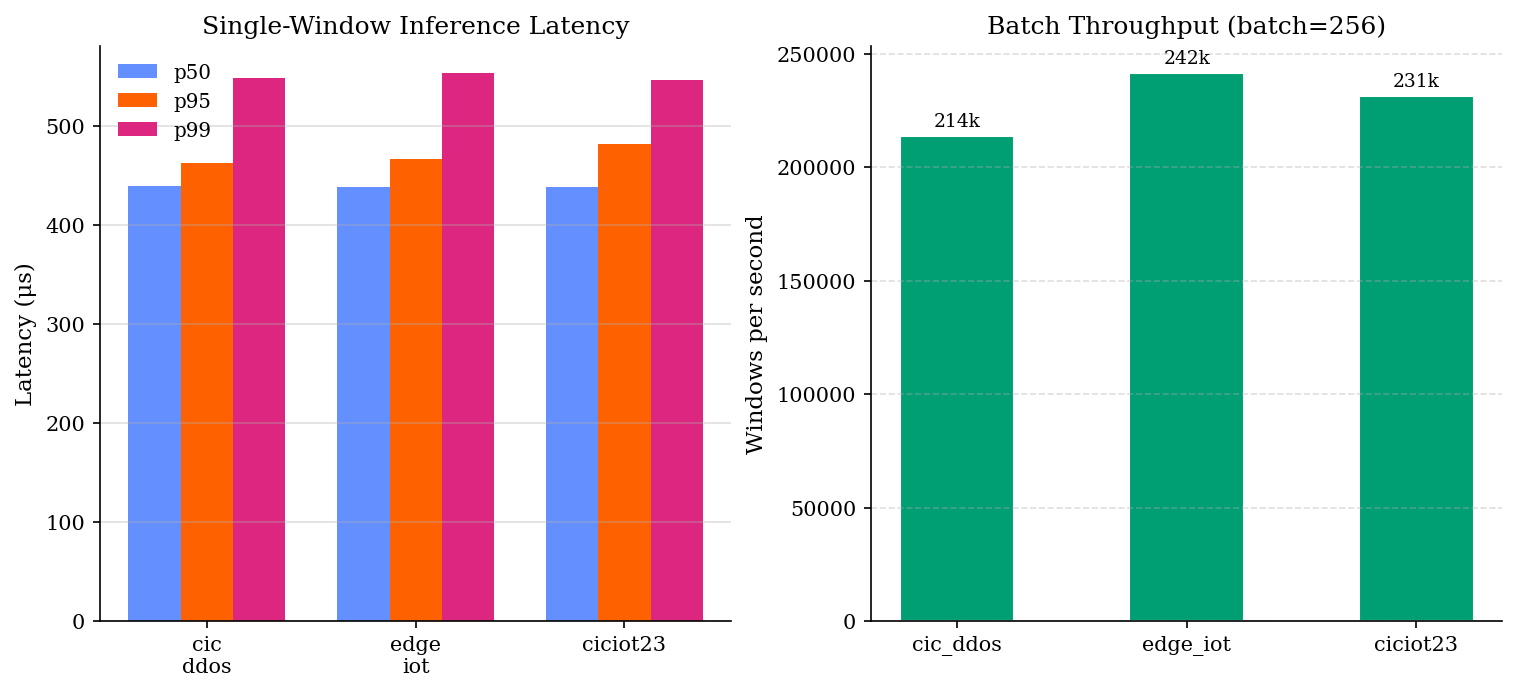

Saved: results\latency_throughput.pdf


In [128]:
# CELL 17: Figures (Part 6): Latency Distribution & Throughput

# Re-collect raw latency arrays for plotting
# (They were computed above, reconstructing from df_bench for the plots)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

# Latency bar (p50, p95, p99)
ax = axes[0]
x  = np.arange(len(bench_results))
w  = 0.25

p50 = [r['Lat p50 (μs)'] for r in bench_results]
p95 = [r['Lat p95 (μs)'] for r in bench_results]
p99 = [r['Lat p99 (μs)'] for r in bench_results]
names_bench = [r['Dataset'] for r in bench_results]

ax.bar(x - w,   p50, w, label='p50',  color='#648FFF')
ax.bar(x,       p95, w, label='p95',  color='#FE6100')
ax.bar(x + w,   p99, w, label='p99',  color='#DC267F')

ax.set_xticks(x)
ax.set_xticklabels([n.replace('_', '\n') for n in names_bench])
ax.set_ylabel('Latency (μs)')
ax.set_title('Single-Window Inference Latency')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle='-', alpha=0.4)

# Throughput bar
ax2 = axes[1]
thr = [r['Throughput (w/s)'] for r in bench_results]
bars = ax2.bar(x, thr, 0.5, color=CBF['Hybrid'], edgecolor='white')

for bar, val in zip(bars, thr):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() * 1.01,
             f'{val/1000:.0f}k', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels([n.replace('-', '\n') for n in names_bench])
ax2.set_ylabel('Windows per second')
ax2.set_title('Batch Throughput (batch=256)')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

fname = OUT / 'latency_throughput.pdf'
fig.savefig(fname, bbox_inches='tight')
fig.savefig(str(fname).replace('.pdf', '.png'), bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved: {fname}')